# A Fast Learning Algorithm for Deep Belief Nets — Summary

# https://www.cs.toronto.edu/~hinton/absps/fastnc.pdf

## Abstract
Hinton, Osindero, and Teh introduce a fast, greedy algorithm for training deep, densely-connected belief networks one layer at a time, using "complementary priors" to eliminate the explaining-away effect that makes inference intractable in directed graphical models. The greedy procedure initializes weights that are subsequently refined with a contrastive form of the wake-sleep algorithm ("up-down" algorithm). Applied to a three-hidden-layer network on MNIST, the resulting generative model achieves 1.25% test error, outperforming well-tuned discriminative backpropagation networks and matching or exceeding support vector machines.

## Problems
- Learning is difficult in directed belief networks with many hidden layers because computing the posterior distribution over hidden units given data is generally intractable due to the "explaining away" phenomenon, where multiple causes become anti-correlated after observing an effect.
- Existing solutions rely on variational approximations, which use a tractable factorial distribution to approximate the true posterior. These approximations can be poor, especially in deep layers, and require joint optimization of all parameters simultaneously, causing learning time to scale poorly with network depth and parameter count.
- Naively applying contrastive divergence learning to deep, multilayer networks with untied weights fails because such networks take too long to reach conditional equilibrium given a clamped data vector.

## Proposed Solutions
- **Complementary priors**: A prior distribution over hidden variables that exactly cancels the correlations induced by the likelihood term, yielding an exactly factorial posterior. The paper proves (via the Hammersley–Clifford theorem) which likelihood functions admit such priors.
- **Infinite directed model with tied weights**: An infinite stack of layers with tied weights is shown to be mathematically equivalent to a Restricted Boltzmann Machine (RBM), since sampling from this infinite net corresponds exactly to alternating Gibbs sampling in an RBM.
- **Greedy layer-wise learning algorithm**: Learn one RBM at a time via contrastive divergence; freeze its weights; transform the data through the learned weights to obtain "higher-level data"; repeat for the next layer. This procedure is guaranteed (in expectation) not to decrease a variational lower bound on the data log-likelihood.
- **Up-down fine-tuning algorithm**: A contrastive variant of the wake-sleep algorithm that back-fits the greedily learned weights. It separates recognition (bottom-up) and generative (top-down) weights, and uses limited Gibbs sampling in the top-level associative memory instead of requiring convergence to equilibrium.

## Purpose
The central motivation is to enable efficient, unsupervised, layer-by-layer learning of deep generative models with many hidden layers and millions of parameters, without the intractability and slow joint optimization of standard variational or wake-sleep approaches, and to demonstrate that such generative models can match or exceed discriminative techniques on a standard benchmark.

## Methodology

### Architecture
A hybrid network (Figure 1/5) in which:
- The top two hidden layers have symmetric, undirected connections forming a Restricted Boltzmann Machine that serves as an associative memory.
- All lower layers use directed, top-down generative connections.
- Bottom-up recognition connections (initially tied to generative weights) infer factorial posterior representations layer by layer.

For MNIST: architecture $784 \rightarrow 500 \rightarrow 500 \leftrightarrow 2000 \leftrightarrow 10$ (label units), totaling about 1.7 million weights.

### Mathematical formulation
- Unit activation probability in a logistic belief net:
$$p(s_i = 1) = \frac{1}{1 + \exp\left(-b_i - \sum_j s_j w_{ij}\right)}$$
- Maximum likelihood learning rule for RBM weights via contrastive divergence:
$$\frac{\partial \log p(v^0)}{\partial w_{ij}} = \langle v_i^0 h_j^0 \rangle - \langle v_i^\infty h_j^\infty \rangle$$
approximated by truncating the Gibbs chain after $n$ steps (contrastive divergence).
- Variational free-energy bound justifying greedy layer addition:
$$\log p(v^0) \geq \sum_{h^0} Q(h^0|v^0)\left[\log p(h^0) + \log p(v^0|h^0)\right] - \sum_{h^0} Q(h^0|v^0)\log Q(h^0|v^0)$$

### Training procedure
1. **Greedy pretraining**: Each layer trained as an RBM using contrastive divergence for 30 epochs, starting from the visible layer and proceeding upward; higher-layer "data" obtained by propagating activation probabilities through frozen lower-layer weights. For the top (associative memory) layer, digit labels are included via a 10-unit softmax group.
2. **Fine-tuning (up-down algorithm)**: 300 additional epochs alternating an "up-pass" (updates generative weights using recognition-inferred states) and a "down-pass" (updates recognition weights using generative-sampled states), with the number of Gibbs iterations in the top-level associative memory increased progressively (3, then 6, then 10 iterations across training phases).
3. **Testing**: A stochastic or deterministic up-pass fixes the penultimate layer states; label units are inferred either via Gibbs sampling or by computing exact free energy for each candidate label.

### Dataset and evaluation
MNIST handwritten digit database (60,000 training / 10,000 test images), evaluated in the "permutation-invariant" setting (no geometric priors or preprocessing), trained on 44,000 images with a held-out 10,000-image validation set, later fine-tuned on the full 60,000-image training set.

## Results
- After greedy pretraining alone: 2.49% test error.
- After up-down fine-tuning (best validation-selected model): 1.39% test error.
- After retraining on the full 60,000-image training set: **1.25% test error**, the paper's headline result.
- Comparison to alternative methods on the permutation-invariant task (Table 1):

| Method | Test Error (%) |
|---|---|
| Generative model (this paper) | 1.25 |
| SVM (degree-9 polynomial kernel) | 1.4 |
| Backprop, 784-500-300-10 | 1.51 |
| Backprop, 784-800-10 | 1.53 |
| Backprop, 784-500-150-10 (online) | 2.95 |
| Nearest neighbor (60,000 examples, L3) | 2.8 |

- The generative model outperforms comparably unconstrained backpropagation networks and slightly outperforms the best-reported SVM, though specialized convolutional networks using geometric priors and data augmentation achieve lower error rates (down to 0.4%).
- Qualitative analysis: the model can generate class-conditional digit images by Gibbs sampling in the top-level associative memory and propagating down through generative connections, illustrating interpretable, structured representations in the deep hidden layers.

## Conclusions
- Deep, densely-connected belief networks can be learned effectively one layer at a time by exploiting the equivalence between infinite directed networks with tied weights and RBMs, avoiding the standard intractability of posterior inference via complementary priors.
- The greedy algorithm provably improves (in expectation) a variational bound on the data likelihood at each added layer, providing a principled foundation despite the approximate nature of contrastive divergence.
- Subsequent up-down fine-tuning corrects the suboptimality of purely greedy training, further improving classification performance.
- The resulting generative model outperforms comparable unconstrained discriminative neural networks and support vector machines on MNIST, empirically demonstrating that unsupervised generative pretraining can produce highly competitive parameter settings, and that each training case constrains generative model parameters more richly (by the number of bits needed to specify the whole input) than discriminative models (constrained only by the bits needed to specify the label).
- The work is presented as a stepping stone toward larger, deeper generative networks, later foundational to the broader development of deep learning (e.g., deep belief networks and layer-wise pretraining strategies).

# Mathematical and Statistical Content — Summary

## 1. Logistic Unit Activation (Eq. 1)
$$p(s_i = 1) = \frac{1}{1 + \exp\left(-b_i - \sum_j s_j w_{ij}\right)}$$
Defines how a stochastic binary unit $i$ turns on: its probability of activation is a logistic (sigmoid) function of a weighted sum of its parent units' states $s_j$, plus a bias $b_i$. This is the basic building block of every layer in the network — it converts a linear combination of inputs into a probability.

## 2. Maximum-Likelihood Gradient for a Single Weight (Eqs. 2–4)
$$\frac{\partial \log p(v^0)}{\partial w_{ij}^{00}} = \langle h_j^0 (v_i^0 - \hat v_i^0) \rangle$$
This is the derivative of the log-probability of a data vector with respect to a generative weight. It says: increase the weight in proportion to the correlation between hidden unit activity and the *difference* between the real data and the model's reconstruction of it. Summing this rule across the infinite tied-weight stack (Eq. 4) causes most terms to cancel, leaving a simple two-term expression — this telescoping cancellation is what connects the infinite directed model to the RBM learning rule.

## 3. RBM Learning Rule via Contrastive Divergence (Eq. 5)
$$\frac{\partial \log p(v^0)}{\partial w_{ij}} = \langle v_i^0 h_j^0 \rangle - \langle v_i^\infty h_j^\infty \rangle$$
The gradient of the log-likelihood equals the difference between two correlations: the "data" correlation between visible and hidden units (measured immediately after clamping data), and the "model" correlation at equilibrium (after infinite Gibbs sampling). This is the standard Boltzmann machine learning rule. Since running to equilibrium ($t=\infty$) is computationally expensive, the paper uses **contrastive divergence**, truncating the Gibbs chain after $n$ steps.

## 4. Contrastive Divergence as a Difference of KL Divergences (Eq. 6)
$$KL(P^0 \| P_\theta^\infty) - KL(P_\theta^n \| P_\theta^\infty)$$
This reformulates what contrastive divergence learning actually minimizes: the gap between two Kullback-Leibler divergences — one measuring how far the data distribution $P^0$ is from the model's equilibrium distribution $P_\theta^\infty$, and one measuring how far the $n$-step Gibbs-sampled distribution $P_\theta^n$ is from that same equilibrium. Since Gibbs sampling always reduces KL divergence to equilibrium, this difference is guaranteed non-negative, justifying the truncated approximation as sound (though biased, since it ignores how $P_\theta^n$ itself depends on the parameters).

## 5. Energy Function of a Directed Model (Eq. 7)
$$E(v^0, h^0) = -\left[\log p(h^0) + \log p(v^0 | h^0)\right]$$
Defines an "energy" for a configuration of visible and hidden units in a directed belief net, analogous to energy in physics-based models (Boltzmann machines). Lower energy corresponds to higher probability. This bridges directed (belief net) and undirected (Boltzmann machine) formalisms.

## 6. Variational Free-Energy Lower Bound (Eq. 8)
$$\log p(v^0) \geq \sum_{h^0} Q(h^0|v^0)\left[\log p(h^0) + \log p(v^0|h^0)\right] - \sum_{h^0} Q(h^0|v^0)\log Q(h^0|v^0)$$
This is the core theoretical justification for greedy layer-wise training. It states that the true log-probability of data is always at least as large as an "expected energy minus entropy" bound, computed using any approximate posterior $Q(h^0|v^0)$ in place of the true (intractable) posterior. The bound is tight (equality) exactly when $Q$ equals the true posterior. The greedy algorithm works because, at the moment a layer is learned with tied weights, $Q$ *is* the true posterior, making the bound exact; improving the bound afterward is guaranteed not to decrease the true log-likelihood.

## 7. Objective for Learning Higher Layers (Eq. 9)
$$\sum_{h^0} Q(h^0|v^0)\log p(h^0)$$
After freezing the lower-layer recognition weights, maximizing the variational bound with respect to higher-layer weights reduces to maximizing this expression — equivalent to training the higher layers as a standard maximum-likelihood model on "data" $h^0$ generated with probability $Q(h^0|v^0)$. This is what licenses treating each layer's output as literal training data for the next RBM.

## 8. Softmax Function for Label Units (Eq. 10)
$$p_i = \frac{\exp(x_i)}{\sum_j \exp(x_j)}$$
Standard softmax: converts a vector of real-valued inputs $x_i$ (one per class label) into a normalized probability distribution over mutually exclusive classes, used for the 10-way digit label representation in the top associative memory. Ensures exactly one label unit is "on" during generation.

## 9. Complementary Priors: General Theory (Eqs. 11–13)
$$P(x|y) = \exp\left(\sum_j \Phi_j(x, y_j) + \beta(x) - \log \Omega(y)\right)$$
$$P(y) = \frac{1}{C}\exp\left(\log \Omega(y) + \sum_j \alpha_j(y_j)\right)$$
These equations characterize, in full generality, exactly which likelihood functions $P(x|y)$ admit a "complementary prior" $P(y)$ — a prior chosen so the resulting posterior $P(y|x)$ factorizes perfectly across the $y_j$. The proof uses the **Hammersley–Clifford theorem**, which states that any positive probability distribution satisfying a given set of conditional-independence relations must factorize according to the cliques of the corresponding undirected graph. Here, the required independencies ($y_j \perp y_k \mid x$) correspond to an undirected bipartite-like graph, forcing the joint distribution into the exponential form of Eq. 13.

## 10. Complementarity for Infinite Stacks (Eqs. 14–17)
$$P(x|y) = \prod_i P(x_i|y), \qquad P(y|x) = \prod_j P(y_j|x)$$
$$P(x,y) = \frac{1}{Z}\exp\left(\sum_{i,j}\Psi_{i,j}(x_i,y_j) + \sum_i \gamma_i(x_i) + \sum_j \alpha_j(y_j)\right)$$
Adding the requirement that *both* directions of the conditional distribution factorize (needed for a valid infinite stack of alternating layers) restricts the joint distribution further, via the Hammersley–Clifford theorem applied to a complete bipartite graph, to this specific pairwise exponential-family form — exactly the form of an RBM's joint distribution.

## 11. Formal Construction of the Infinite Directed Stack (Eqs. 18–30)
Defines an infinite sequence of variables $x^{(0)}, y^{(0)}, x^{(1)}, y^{(1)}, \dots$ with Markovian transition distributions $g_x, g_y$ derived from the RBM joint distribution $f(x,y)$, and proves by induction that:
$$P(x^{(i)}) = f_x(x^{(i)}), \qquad P(y^{(i)}) = f_y(y^{(i)})$$
for all layers $i$, and that the "downward" conditional distributions match the same $g_x, g_y$ used "upward." This formally establishes that an infinite directed belief net with tied weights is statistically equivalent to alternating Gibbs sampling in an RBM — the mathematical foundation allowing a directed multi-layer generative model to be learned by RBM-style contrastive divergence.

## Role of Statistical/Optimization Method Used in Practice
- **Contrastive Divergence (CD)**: The practical learning algorithm substituting full maximum likelihood; approximates the intractable equilibrium expectation with a short Gibbs chain (1 full step in most experiments), trading theoretical exactness for computational feasibility.
- **Gibbs Sampling**: Used throughout — both for CD training and for generating samples/testing — alternately sampling hidden units given visible units and vice versa, converging toward the model's equilibrium (stationary) distribution.
- **Wake-Sleep / Up-Down Algorithm**: A two-phase (bottom-up "wake" and top-down "sleep") stochastic gradient procedure that separately updates generative and recognition weights, using sampled states rather than exact expectations, with variance reduced by averaging or using deterministic (probability-based) passes at test time.

## Summary of Mathematical Role in the Paper
The mathematics serves three purposes: (1) proving that complementary priors exist and characterizing them exactly (Hammersley–Clifford-based derivations), (2) establishing the equivalence between infinite tied-weight directed nets and RBMs (justifying the use of contrastive divergence for directed models), and (3) providing a variational bound guaranteeing that greedy, layer-by-layer training never degrades — and often improves — the overall generative model's likelihood.

# Problems, Limitations, and Proposed Solutions

| # | Key Problem / Research Gap | How It Limits Prior Work | Proposed Solution in This Paper |
|---|---|---|---|
| 1 | Inference in densely-connected, multilayer directed belief nets is intractable due to the "explaining away" effect (hidden causes become correlated in the posterior once data is observed). | Exact inference is impossible except in special cases (e.g., mixture models, linear-Gaussian models); this blocks efficient computation of learning gradients in general directed nets. | Introduce **complementary priors** — priors constructed so that, when combined with the likelihood, the resulting posterior factorizes exactly, eliminating explaining away analytically rather than approximately. |
| 2 | Variational methods approximate the true posterior with a simpler, factorial distribution to make learning tractable. | The approximation can be poor, particularly at the deepest hidden layer where independence assumptions are least justified; also, all parameters must be learned jointly, causing learning time to scale poorly with model size. | Show that under a complementary prior, the true posterior *is* factorial, removing the need for a variational approximation at the point where each layer is learned; enables **layer-by-layer** rather than joint parameter learning. |
| 3 | Markov Chain Monte Carlo (MCMC) methods can sample from the true posterior but are computationally very expensive. | Impractical for learning large, deep networks, especially with many parameters and layers. | Exploit the equivalence between an infinite directed net with tied weights and a Restricted Boltzmann Machine (RBM), allowing exact posterior sampling via a simple bottom-up pass rather than prolonged MCMC. |
| 4 | Naively applying contrastive divergence (CD) learning to deep, multilayer networks with untied weights fails. | Such networks take far too long to reach *conditional* equilibrium given a clamped data vector, making CD training computationally infeasible for deep architectures. | Propose a **greedy learning algorithm** that trains one RBM-equivalent layer at a time via CD, freezes it, and transforms the data through the learned weights to create "data" for the next layer — avoiding the need for joint deep equilibrium sampling. |
| 5 | Greedy, layer-wise learning is not optimal: once higher layers are learned, the weights and simple inference procedure used for lower layers are no longer ideal. | Under-fitting can result, particularly problematic for unsupervised generative models trained on large, high-dimensional datasets where each case constrains many parameters. | Introduce a **back-fitting stage** using a contrastive version of the wake-sleep algorithm (the "up-down" algorithm), which jointly refines generative and recognition weights across layers after greedy pretraining. |
| 6 | The standard wake-sleep algorithm suffers from "mode-averaging": recognition weights may fail to capture multiple equally valid explanations for the same data, and its sleep phase requires prolonged Gibbs sampling to reach the true equilibrium distribution of the top-level model. | Leads to poor recognition weights and computationally expensive training. | Use a **contrastive form of wake-sleep**: initialize the top-level associative memory via an up-pass and run only a few iterations of Gibbs sampling before the down-pass, mitigating mode-averaging and removing the need for full equilibrium sampling. |
| 7 | It was unclear whether a purely generative, unsupervised-pretrained deep model could match the classification performance of state-of-the-art discriminative models (e.g., backpropagation networks, SVMs) without hand-crafted, domain-specific architecture (e.g., convolution, weight-sharing). | Discriminative methods were generally assumed superior for pattern recognition tasks such as digit classification, especially in "permutation-invariant" settings without geometric priors. | Empirically validate the greedy + up-down approach on the MNIST digit dataset, achieving 1.25% test error — outperforming standard backpropagation networks and matching/exceeding published SVM results, demonstrating the viability of deep generative pretraining. |

In [1]:
# !pip -q install datasets scikit-learn

# =============================================================================
# "A Fast Learning Algorithm for Deep Belief Nets" (Hinton, Osindero, Teh, 2006)
# Educational, simplified, faithful-in-spirit PyTorch replication on CIFAR-10.
#
# CORE IDEAS FROM THE PAPER (kept intact here):
#   - Deep, densely-connected directed belief nets are hard to train jointly
#     because "explaining away" makes exact posterior inference intractable.
#   - A "complementary prior" is a prior over hidden causes that, combined
#     with the likelihood, makes the true posterior factorial (independent
#     units), removing the need for expensive/approximate inference.
#   - An infinite directed net with TIED weights is mathematically equivalent
#     to a Restricted Boltzmann Machine (RBM): sampling top-down through the
#     infinite tied-weight stack is the same as alternating Gibbs sampling.
#   - This equivalence licenses a GREEDY, layer-by-layer learning algorithm:
#       1. Train the bottom pair of layers as an RBM with Contrastive
#          Divergence (CD).
#       2. FREEZE those weights, and use them to map data upward into a new,
#          higher-level "data" representation (the hidden probabilities).
#       3. Train the next RBM on that new representation.
#       4. Repeat. The top TWO layers are left as an undirected associative
#          memory (a plain RBM); all layers below become directed top-down
#          generative connections once "untied" from the layer above.
#   - After greedy pretraining, bottom-up ("recognition") and top-down
#     ("generative") weights can be treated separately and refined with a
#     contrastive form of the wake-sleep algorithm (the "up-down" algorithm).
#   - Labels can be folded in as extra visible units on the top associative
#     memory, letting the model learn a JOINT distribution over image
#     features and class label -- classification then falls out of the
#     generative model via free energy, not a discriminative softmax head.
#
# This script builds a heavily reduced CIFAR-10 analogue of the paper's
# 784->500->500<->2000 MNIST network, is class-organized, well commented for
# beginners, and produces a final GridSpec dashboard. It performs NO backprop
# to train the RBMs -- all RBM parameter updates are manual, using
# Contrastive Divergence statistics, exactly as in the paper.
# =============================================================================

import os
import io
import math
import random
from io import BytesIO

import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset, TensorDataset

import torchvision.transforms as T

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import gridspec

from datasets import load_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, accuracy_score

from PIL import Image
from IPython.display import display, Image as IPImage

In [2]:
# =============================================================================
# 0. GLOBAL CONFIG / REPRODUCIBILITY
# =============================================================================

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Architecture -----------------------------------------------------------
# NOTE: The original paper used a much larger architecture:
#   784 (28x28 MNIST pixels) -> 500 -> 500 <-> 2000 (top associative memory)
#   trained on 44,000-60,000 examples for hundreds of epochs.
# Here we drastically shrink everything for a runnable educational demo on a
# small CIFAR-10 subset:
#   256 (16x16 grayscale) -> 128 -> 64 <-> 128 (top associative memory, with
#   10 label units concatenated onto the 64-dim image features).
IMAGE_VISIBLE_DIM = 256
HIDDEN_DIM_1 = 128
HIDDEN_DIM_2 = 64
NUM_CLASSES = 10
TOP_VISIBLE_DIM = HIDDEN_DIM_2 + NUM_CLASSES  # 64 + 10 = 74
TOP_HIDDEN_DIM = 128

# ---- Input representation ----------------------------------------------------
STOCHASTIC_INPUT = False  # Use deterministic real-valued Bernoulli "probabilities"

# ---- Training hyperparameters -------------------------------------------------
PRETRAIN_EPOCHS = 5      # Exactly 5 epochs per RBM, applied independently per stage
CD_K = 1                 # CD-1: one step of Gibbs sampling per update
BATCH_SIZE = 64
LEARNING_RATE = 0.05
INITIAL_MOMENTUM = 0.5
FINAL_MOMENTUM = 0.9
WEIGHT_DECAY = 1e-4

N_TRAIN_SUBSET = 2000
N_TEST_SUBSET = 400

RUN_UP_DOWN_FINE_TUNING = False   # Optional, disabled by default (Sec. 30)
RUN_LINEAR_PROBE = True           # Optional diagnostic only (Sec. 31)

CLASS_NAMES = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
]

EPS = 1e-6  # numerical stability epsilon

In [3]:
# =============================================================================
# 1. WHITE MATPLOTLIB THEME (never dark)
# =============================================================================

def set_white_theme():
    """
    Enforce a clean, publication-style WHITE theme everywhere:
    white figure/axes backgrounds, black text, light-grey gridlines.
    This is purely cosmetic / has nothing to do with the DBN math, but the
    spec requires a consistent readable theme for every figure.
    """
    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "axes.edgecolor": "black",
        "axes.labelcolor": "black",
        "text.color": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "axes.titlecolor": "black",
        "legend.edgecolor": "black",
        "grid.color": "#d9d9d9",
        "grid.linestyle": "--",
        "grid.linewidth": 0.5,
        "font.size": 9,
    })

set_white_theme()

In [ ]:
# =============================================================================
# 2. DATASET -- HuggingFace CIFAR-10 ONLY (never torchvision.datasets.CIFAR10)
# =============================================================================

print("Loading CIFAR-10 from HuggingFace datasets ('uoft-cs/cifar10')...")
ds = load_dataset("uoft-cs/cifar10")


class HFCIFAR10Dataset(Dataset):
    """
    Thin wrapper around a HuggingFace CIFAR-10 split.
    Reads the PIL image from the 'img' field and the integer label from the
    'label' field, applies a torchvision transform, and returns
    (image_tensor, label).
    """
    def __init__(self, hf_split, transform):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        item = self.hf_split[idx]
        img = item["img"]
        if img.mode != "RGB":
            img = img.convert("RGB")
        img = self.transform(img)
        label = int(item["label"])
        return img, label


IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((64, 64)),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

test_transform = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

full_train_dataset = HFCIFAR10Dataset(ds["train"], train_transform)
full_test_dataset = HFCIFAR10Dataset(ds["test"], test_transform)

train_subset = Subset(full_train_dataset, list(range(N_TRAIN_SUBSET)))
test_subset = Subset(full_test_dataset, list(range(N_TEST_SUBSET)))

pin_mem = torch.cuda.is_available()

train_loader = DataLoader(
    train_subset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=pin_mem
)
test_loader = DataLoader(
    test_subset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=pin_mem
)

In [5]:
# =============================================================================
# 3. INPUT REPRESENTATION: RGB -> grayscale -> 16x16 -> flattened [0,1] vector
# =============================================================================
#
# WHY THIS STEP MATTERS:
# The original paper models each visible pixel as (approximately) a Bernoulli
# probability in [0, 1] -- reasonable for near-binary MNIST strokes, but a
# much weaker approximation for natural, continuous-toned CIFAR-10 images.
# We keep the spirit of the paper by producing a [0, 1]-valued "probability"
# vector per image, while being explicit that this is a simplification.

def undo_imagenet_normalization(x):
    """Invert the Normalize(mean, std) transform back to raw [0, 1] pixel range."""
    mean = torch.tensor(IMAGENET_MEAN, device=x.device).view(1, 3, 1, 1)
    std = torch.tensor(IMAGENET_STD, device=x.device).view(1, 3, 1, 1)
    x = x * std + mean
    return x.clamp(0.0, 1.0)


def to_visible_probabilities(rgb_batch):
    """
    Convert a normalized RGB batch (B, 3, 64, 64) into a (B, 256) vector of
    Bernoulli-style visible "probabilities", following the paper's
    convention of treating pixel intensities as activation probabilities.

    Steps:
      1. Undo ImageNet normalization -> pixels back in [0, 1].
      2. Convert RGB -> grayscale (simple luminance-weighted average).
      3. Adaptive average pool to 16x16.
      4. Flatten to 256 values.
    """
    rgb01 = undo_imagenet_normalization(rgb_batch)
    # Standard luminance weights for RGB -> grayscale
    weights = torch.tensor([0.299, 0.587, 0.114], device=rgb_batch.device).view(1, 3, 1, 1)
    gray = (rgb01 * weights).sum(dim=1, keepdim=True)  # (B, 1, 64, 64)
    pooled = F.adaptive_avg_pool2d(gray, output_size=(16, 16))  # (B, 1, 16, 16)
    flat = pooled.view(pooled.size(0), -1).clamp(0.0, 1.0)  # (B, 256)
    return flat


def maybe_binarize(visible_probabilities):
    """
    Optionally sample binary visible states from the continuous
    probabilities via torch.bernoulli(). Controlled by STOCHASTIC_INPUT.
    Deterministic real-valued inputs are used by default (more stable for
    this tiny educational setup).
    """
    if STOCHASTIC_INPUT:
        return torch.bernoulli(visible_probabilities)
    return visible_probabilities

In [6]:
# =============================================================================
# 4. THE BERNOULLI RESTRICTED BOLTZMANN MACHINE (RBM)
# =============================================================================
#
# WHAT IS AN RBM?
# A Restricted Boltzmann Machine has one visible layer and one hidden layer
# with NO within-layer connections. Because there are no intra-layer
# connections, both conditional distributions p(h|v) and p(v|h) factorize
# completely across units -- this is exactly the "factorial posterior"
# property that a complementary prior would guarantee in a directed model.
# This is why RBMs are tractable where general directed nets are not.
#
# ENERGY FUNCTION:
#   E(v, h) = - v^T W h - b_visible^T v - b_hidden^T h
# Lower energy <=> higher probability: p(v, h) = exp(-E(v,h)) / Z
# The partition function Z sums over all visible/hidden configurations and
# is intractable for any non-trivial model size -- so we NEVER attempt to
# compute exact likelihoods here, only proxies like reconstruction error,
# free energy, and pseudo-likelihood.

class BernoulliRBM:
    """
    A single Restricted Boltzmann Machine with Bernoulli visible and hidden
    units, trained by manual Contrastive Divergence updates (no autograd).
    """

    def __init__(self, n_visible, n_hidden, name="RBM"):
        self.name = name
        self.n_visible = n_visible
        self.n_hidden = n_hidden

        # Small, zero-centered random weights (Sec. 19)
        self.W = (torch.randn(n_visible, n_hidden, device=DEVICE) * 0.01)
        self.visible_bias = torch.zeros(n_visible, device=DEVICE)
        self.hidden_bias = torch.zeros(n_hidden, device=DEVICE)

        # Momentum buffers for manual gradient-ascent updates
        self.velocity_W = torch.zeros_like(self.W)
        self.velocity_visible_bias = torch.zeros_like(self.visible_bias)
        self.velocity_hidden_bias = torch.zeros_like(self.hidden_bias)

    # ---- Initialization helper (Sec. 19) ------------------------------------
    def init_visible_bias_from_data(self, mean_visible):
        """
        Initialize visible biases from empirical activation probabilities:
            b_visible_i = log( p_i / (1 - p_i) )
        This is the logit of the mean activation of each visible unit,
        giving the RBM a sensible starting point (matching marginal
        statistics before any weight updates).
        """
        mean_visible = mean_visible.clamp(EPS, 1.0 - EPS)
        self.visible_bias = torch.log(mean_visible / (1.0 - mean_visible)).to(DEVICE)

    # ---- Conditional distributions (Sec. 8) ---------------------------------
    def hidden_probabilities(self, visible):
        """
        p(h_j = 1 | v) = sigmoid(b_hidden_j + sum_i v_i W_ij)
        All hidden units are updated in parallel (this vectorized form does
        exactly that). Because there are no hidden-hidden connections, this
        conditional distribution is exactly factorial -- no approximation
        needed, unlike inference in a general deep directed net.
        """
        return torch.sigmoid(visible @ self.W + self.hidden_bias)

    def sample_hidden(self, visible):
        probs = self.hidden_probabilities(visible)
        return torch.bernoulli(probs), probs

    def visible_probabilities(self, hidden):
        """
        p(v_i = 1 | h) = sigmoid(b_visible_i + sum_j h_j W_ij)
        Also exactly factorial across visible units, for the same reason.
        """
        return torch.sigmoid(hidden @ self.W.t() + self.visible_bias)

    def sample_visible(self, hidden):
        probs = self.visible_probabilities(hidden)
        return torch.bernoulli(probs), probs

    def gibbs_step(self, visible):
        """One full step of alternating Gibbs sampling: v -> h -> v."""
        h_sample, h_prob = self.sample_hidden(visible)
        v_sample, v_prob = self.sample_visible(h_sample)
        return v_sample, v_prob, h_sample, h_prob

    # ---- Energy / free energy (Sec. 7) --------------------------------------
    def compute_energy(self, visible, hidden):
        """
        E(v, h) = -v^T W h - b_visible^T v - b_hidden^T h
        Returns one energy value per example in the batch.
        """
        term_interaction = (visible @ self.W * hidden).sum(dim=1)
        term_visible = visible @ self.visible_bias
        term_hidden = hidden @ self.hidden_bias
        return -(term_interaction + term_visible + term_hidden)

    def free_energy(self, visible):
        """
        F(v) = -b_visible^T v - sum_j softplus(b_hidden_j + v^T W_j)
        The hidden units have been analytically summed out. Note:
            p(v) = exp(-F(v)) / Z
        Z (the partition function) is intractable at this scale, so free
        energy is used only as a RELATIVE score (e.g., to compare candidate
        labels or track training progress), never as an exact probability.
        """
        visible_term = visible @ self.visible_bias
        wx_b = visible @ self.W + self.hidden_bias
        hidden_term = F.softplus(wx_b).sum(dim=1)
        return -(visible_term + hidden_term)

    def pseudo_likelihood(self, visible):
        """
        Cheap stochastic approximation to log-likelihood: flip one random
        visible unit per example and compare free energies. This is a
        standard tractable proxy used to monitor RBM training without ever
        computing the true (intractable) partition function.
        """
        v = visible.clone()
        n_features = v.size(1)
        idx = torch.randint(0, n_features, (v.size(0),), device=v.device)
        v_flip = v.clone()
        flip_vals = 1.0 - v_flip[torch.arange(v.size(0)), idx]
        v_flip[torch.arange(v.size(0)), idx] = flip_vals

        fe_v = self.free_energy(v)
        fe_flip = self.free_energy(v_flip)
        # log sigmoid of the free-energy gap, scaled by number of features
        pl = n_features * F.logsigmoid(fe_flip - fe_v)
        return pl.mean().item()

    def reconstruct(self, visible, k=1):
        """Run k Gibbs steps starting from `visible` and return final v_prob."""
        v = visible
        for _ in range(k):
            _, v_prob, h_sample, _ = self.gibbs_step(v)
            v = v_prob
        return v

    # ---- Contrastive Divergence statistics (Sec. 9) -------------------------
    def contrastive_divergence(self, visible, k=1):
        """
        CD-k: an approximation to the maximum-likelihood gradient that does
        NOT wait for the Markov chain to reach equilibrium. It uses:
            positive phase: correlations measured with data clamped on v
            negative phase: correlations measured after k Gibbs steps
        Returns all the statistics needed for a manual weight update, plus a
        dictionary of monitoring metrics.
        """
        batch_size = visible.size(0)

        # ---- Positive phase --------------------------------------------
        v0 = visible
        ph0 = self.hidden_probabilities(v0)
        positive_association = (v0.t() @ ph0) / batch_size

        # ---- Negative phase (k steps of Gibbs sampling) -----------------
        h0_sample = torch.bernoulli(ph0)
        vk_prob = v0
        hk_prob = ph0
        v_current = h0_sample
        vk_prob = self.visible_probabilities(h0_sample)
        hk_prob = self.hidden_probabilities(vk_prob)
        # Additional Gibbs steps if k > 1
        for _ in range(k - 1):
            hk_sample = torch.bernoulli(hk_prob)
            vk_prob = self.visible_probabilities(hk_sample)
            hk_prob = self.hidden_probabilities(vk_prob)

        negative_association = (vk_prob.t() @ hk_prob) / batch_size

        weight_direction = positive_association - negative_association
        visible_bias_direction = (v0 - vk_prob).mean(dim=0)
        hidden_bias_direction = (ph0 - hk_prob).mean(dim=0)

        metrics = {
            "recon_bce": F.binary_cross_entropy(
                vk_prob.clamp(EPS, 1 - EPS), v0.clamp(0, 1), reduction="mean"
            ).item(),
            "recon_mse": F.mse_loss(vk_prob, v0).item(),
            "recon_acc": ((vk_prob > 0.5).float() == (v0 > 0.5).float()).float().mean().item(),
            "data_free_energy": self.free_energy(v0).mean().item(),
            "recon_free_energy": self.free_energy(vk_prob).mean().item(),
            "positive_assoc_norm": positive_association.norm().item(),
            "negative_assoc_norm": negative_association.norm().item(),
            "association_contrast": weight_direction.norm().item(),
            "mean_hidden_activation": ph0.mean().item(),
            "hidden_sparsity": (ph0 < 0.1).float().mean().item(),
        }

        return weight_direction, visible_bias_direction, hidden_bias_direction, metrics

    # ---- Manual parameter update (Sec. 10) ----------------------------------
    def manual_update(self, positive_association, negative_association,
                       visible_bias_direction, hidden_bias_direction,
                       learning_rate, momentum, weight_decay):
        """
        Manual, momentum-based gradient ASCENT on the log-likelihood
        approximation (we ascend because we want to increase log p(data)).
        No torch.optim / no autograd -- everything is explicit, matching the
        paper's hand-written update equations (Appendix B pseudo-code).

        NOTE: the caller passes `positive_association - negative_association`
        already combined as `weight_direction`, but the signature keeps both
        names available for clarity per the spec; here we treat
        `positive_association` as the already-combined weight_direction and
        `negative_association` as unused (kept for interface compatibility).
        """
        weight_direction = positive_association  # already (pos - neg)
        with torch.no_grad():
            self.velocity_W = (
                momentum * self.velocity_W
                + learning_rate * (weight_direction - weight_decay * self.W)
            )
            self.velocity_visible_bias = (
                momentum * self.velocity_visible_bias
                + learning_rate * visible_bias_direction
            )
            self.velocity_hidden_bias = (
                momentum * self.velocity_hidden_bias
                + learning_rate * hidden_bias_direction
            )

            self.W += self.velocity_W
            self.visible_bias += self.velocity_visible_bias
            self.hidden_bias += self.velocity_hidden_bias

    def num_parameters(self):
        return self.W.numel() + self.visible_bias.numel() + self.hidden_bias.numel()

In [7]:
# =============================================================================
# 5. TOP-LEVEL ASSOCIATIVE-MEMORY RBM WITH A SOFTMAX LABEL GROUP
# =============================================================================
#
# The paper's top two layers form an undirected associative memory that
# additionally models a "softmax group" of label units. We subclass the
# plain BernoulliRBM to override only the visible-side conditional, since
# the LAST 10 visible units must compete via softmax (exactly one label
# active) instead of behaving as independent sigmoid units.

class TopAssociativeMemoryRBM(BernoulliRBM):
    """
    Top-level RBM whose visible layer is:
        [ 64 image-feature (sigmoid) units | 10 label (softmax) units ]
    connected undirectedly to 128 top hidden units. This constitutes the
    associative memory described in Section 4 (Fig. 5) of the paper.
    """

    def __init__(self, n_feature_visible, n_label_visible, n_hidden, name="TopRBM"):
        super().__init__(n_feature_visible + n_label_visible, n_hidden, name=name)
        self.n_feature_visible = n_feature_visible
        self.n_label_visible = n_label_visible

    def visible_probabilities(self, hidden):
        """
        p(feature_i = 1 | h) = sigmoid(...)      [independent units]
        p(label_i    = 1 | h) = softmax(...)     [competing "softmax group"]
        Returns the concatenation of both blocks.
        """
        logits = hidden @ self.W.t() + self.visible_bias
        feature_logits = logits[:, : self.n_feature_visible]
        label_logits = logits[:, self.n_feature_visible:]

        feature_probabilities = torch.sigmoid(feature_logits)
        label_probabilities = F.softmax(label_logits, dim=1)
        return torch.cat([feature_probabilities, label_probabilities], dim=1)

    def sample_visible(self, hidden):
        """
        Sample feature units independently (Bernoulli) and sample exactly
        ONE active label unit (categorical / multinomial), then re-encode
        the sampled label as one-hot before concatenating.
        Explanatory note: competition among label units changes their
        activation PROBABILITIES (via softmax normalization) but the local,
        correlation-based CD weight update rule is unaffected -- the same
        <v_i h_j> statistics are used regardless of whether v_i belongs to
        an independent-sigmoid block or a competing-softmax block.
        """
        probs = self.visible_probabilities(hidden)
        feature_probabilities = probs[:, : self.n_feature_visible]
        label_probabilities = probs[:, self.n_feature_visible:]

        feature_samples = torch.bernoulli(feature_probabilities)
        label_index = torch.multinomial(label_probabilities.clamp_min(EPS), 1).squeeze(1)
        label_onehot = F.one_hot(label_index, num_classes=self.n_label_visible).float()

        v_sample = torch.cat([feature_samples, label_onehot], dim=1)
        return v_sample, probs

In [8]:
# =============================================================================
# 6. GREEDY LAYER-WISE PRETRAINING LOOP (generic driver)
# =============================================================================

def momentum_for_epoch(epoch_idx):
    """Momentum schedule: 0.5 for the first two epochs, 0.9 afterward (Sec. 20)."""
    return INITIAL_MOMENTUM if epoch_idx < 2 else FINAL_MOMENTUM


def train_rbm_greedy(rbm, train_data_loader_fn, val_data_fn, epochs, cd_k, tag):
    """
    Generic greedy-training loop for one RBM stage.

    train_data_loader_fn: callable() -> iterable of (visible_batch,) or
                           (visible_batch, extra) tuples for this stage
    val_data_fn:           callable() -> (visible_val_tensor,) for validation

    Returns a metrics history dict (one list per tracked quantity, one entry
    per epoch) so it can feed the dashboard later.
    """
    history = {
        "train_bce": [], "val_bce": [],
        "train_mse": [], "val_mse": [],
        "train_acc": [], "val_acc": [],
        "data_free_energy": [], "recon_free_energy": [],
        "positive_assoc_norm": [], "negative_assoc_norm": [],
        "association_contrast": [],
        "weight_update_norm": [], "vbias_update_norm": [], "hbias_update_norm": [],
        "mean_hidden_activation": [], "hidden_sparsity": [],
        "pseudo_likelihood": [], "weight_norm": [],
    }

    for epoch in range(epochs):
        momentum = momentum_for_epoch(epoch)
        epoch_bce, epoch_mse, epoch_acc = [], [], []
        epoch_pos, epoch_neg, epoch_contrast = [], [], []
        epoch_dfe, epoch_rfe = [], []
        epoch_mean_h, epoch_sparsity = [], []
        epoch_wnorm, epoch_vbnorm, epoch_hbnorm = [], [], []

        for visible_batch in train_data_loader_fn():
            visible_batch = visible_batch.to(DEVICE)
            (weight_direction, visible_bias_direction,
             hidden_bias_direction, metrics) = rbm.contrastive_divergence(visible_batch, k=cd_k)

            rbm.manual_update(
                positive_association=weight_direction,
                negative_association=None,
                visible_bias_direction=visible_bias_direction,
                hidden_bias_direction=hidden_bias_direction,
                learning_rate=LEARNING_RATE,
                momentum=momentum,
                weight_decay=WEIGHT_DECAY,
            )

            epoch_bce.append(metrics["recon_bce"])
            epoch_mse.append(metrics["recon_mse"])
            epoch_acc.append(metrics["recon_acc"])
            epoch_pos.append(metrics["positive_assoc_norm"])
            epoch_neg.append(metrics["negative_assoc_norm"])
            epoch_contrast.append(metrics["association_contrast"])
            epoch_dfe.append(metrics["data_free_energy"])
            epoch_rfe.append(metrics["recon_free_energy"])
            epoch_mean_h.append(metrics["mean_hidden_activation"])
            epoch_sparsity.append(metrics["hidden_sparsity"])
            epoch_wnorm.append(rbm.velocity_W.norm().item())
            epoch_vbnorm.append(rbm.velocity_visible_bias.norm().item())
            epoch_hbnorm.append(rbm.velocity_hidden_bias.norm().item())

        # ---- Validation (no parameter updates) ------------------------------
        with torch.no_grad():
            v_val = val_data_fn().to(DEVICE)
            v_val_recon = rbm.reconstruct(v_val, k=1)
            val_bce = F.binary_cross_entropy(
                v_val_recon.clamp(EPS, 1 - EPS), v_val.clamp(0, 1), reduction="mean"
            ).item()
            val_mse = F.mse_loss(v_val_recon, v_val).item()
            val_acc = ((v_val_recon > 0.5).float() == (v_val > 0.5).float()).float().mean().item()
            pl = rbm.pseudo_likelihood(v_val)

        history["train_bce"].append(float(np.mean(epoch_bce)))
        history["val_bce"].append(val_bce)
        history["train_mse"].append(float(np.mean(epoch_mse)))
        history["val_mse"].append(val_mse)
        history["train_acc"].append(float(np.mean(epoch_acc)))
        history["val_acc"].append(val_acc)
        history["data_free_energy"].append(float(np.mean(epoch_dfe)))
        history["recon_free_energy"].append(float(np.mean(epoch_rfe)))
        history["positive_assoc_norm"].append(float(np.mean(epoch_pos)))
        history["negative_assoc_norm"].append(float(np.mean(epoch_neg)))
        history["association_contrast"].append(float(np.mean(epoch_contrast)))
        history["weight_update_norm"].append(float(np.mean(epoch_wnorm)))
        history["vbias_update_norm"].append(float(np.mean(epoch_vbnorm)))
        history["hbias_update_norm"].append(float(np.mean(epoch_hbnorm)))
        history["mean_hidden_activation"].append(float(np.mean(epoch_mean_h)))
        history["hidden_sparsity"].append(float(np.mean(epoch_sparsity)))
        history["pseudo_likelihood"].append(pl)
        history["weight_norm"].append(rbm.W.norm().item())

        print(f"[{tag}] epoch {epoch+1}/{epochs} | "
              f"train BCE={history['train_bce'][-1]:.4f} "
              f"val BCE={val_bce:.4f} "
              f"train acc={history['train_acc'][-1]:.3f} "
              f"val acc={val_acc:.3f} "
              f"PL={pl:.3f}")

    return history

In [9]:
# =============================================================================
# 7. STAGE 0: BUILD THE RAW VISIBLE (PIXEL) DATASETS FOR TRAIN / TEST
# =============================================================================

def collect_visible_and_labels(loader):
    """Run every batch through the RGB->grayscale->16x16 pipeline and cache it."""
    all_visible, all_labels = [], []
    for images, labels in loader:
        images = images.to(DEVICE)
        v = to_visible_probabilities(images)
        v = maybe_binarize(v)
        all_visible.append(v.detach().cpu())
        all_labels.append(labels)
    return torch.cat(all_visible, dim=0), torch.cat(all_labels, dim=0)


print("Building pooled-grayscale visible datasets...")
train_visible_all, train_labels_all = collect_visible_and_labels(train_loader)
test_visible_all, test_labels_all = collect_visible_and_labels(test_loader)

Building pooled-grayscale visible datasets...


In [10]:
# =============================================================================
# 8. SANITY CHECKS (Sec. 21)
# =============================================================================

print("\n===== SANITY CHECK =====")
print("Number of training samples:", len(train_visible_all))
print("Number of test samples:", len(test_visible_all))

sample_batch_images, sample_batch_labels = next(iter(train_loader))
print("Original image batch shape:", tuple(sample_batch_images.shape))

sample_pooled = to_visible_probabilities(sample_batch_images.to(DEVICE))
print("Pooled grayscale shape:", tuple(sample_pooled.shape[:1]) + (16, 16))
print("Flattened visible shape:", tuple(sample_pooled.shape))
print("Visible-value range: [%.4f, %.4f]" % (sample_pooled.min().item(), sample_pooled.max().item()))
print("Label range: [%d, %d]" % (int(train_labels_all.min()), int(train_labels_all.max())))
print("First eight labels:", train_labels_all[:8].tolist())
print("First eight class names:", [CLASS_NAMES[i] for i in train_labels_all[:8].tolist()])

assert train_labels_all.min() >= 0 and train_labels_all.max() <= 9, "Labels out of range"
assert sample_pooled.min() >= -EPS and sample_pooled.max() <= 1 + EPS, "Visible probs out of [0,1]"
assert torch.isfinite(train_visible_all).all(), "Non-finite visible values"


===== SANITY CHECK =====
Number of training samples: 2000
Number of test samples: 400
Original image batch shape: (64, 3, 64, 64)
Pooled grayscale shape: (64, 16, 16)
Flattened visible shape: (64, 256)
Visible-value range: [0.0018, 1.0000]
Label range: [0, 9]
First eight labels: [4, 1, 6, 4, 7, 3, 4, 8]
First eight class names: ['deer', 'automobile', 'frog', 'deer', 'horse', 'cat', 'deer', 'ship']


In [11]:
# =============================================================================
# 9. STAGE 1: BOTTOM RBM  (256 visible <-> 128 hidden)
# =============================================================================

print("\n===== STAGE 1: Training RBM_1 (256 <-> 128) =====")
rbm1 = BernoulliRBM(IMAGE_VISIBLE_DIM, HIDDEN_DIM_1, name="RBM_1")
rbm1.init_visible_bias_from_data(train_visible_all.mean(dim=0))

print("RBM 1 weight shape:", tuple(rbm1.W.shape))
assert rbm1.W.shape == (IMAGE_VISIBLE_DIM, HIDDEN_DIM_1)


def rbm1_train_batches():
    perm = torch.randperm(train_visible_all.size(0))
    shuffled = train_visible_all[perm]
    for i in range(0, shuffled.size(0), BATCH_SIZE):
        yield shuffled[i:i + BATCH_SIZE]


def rbm1_val_data():
    return test_visible_all


history_rbm1 = train_rbm_greedy(
    rbm1, rbm1_train_batches, rbm1_val_data, PRETRAIN_EPOCHS, CD_K, tag="RBM_1"
)

# ---- Freeze RBM_1, compute p(h1|v) as the new dataset for Stage 2 ----------
with torch.no_grad():
    h1_train_probs = rbm1.hidden_probabilities(train_visible_all.to(DEVICE)).cpu()
    h1_test_probs = rbm1.hidden_probabilities(test_visible_all.to(DEVICE)).cpu()

assert h1_train_probs.min() >= -EPS and h1_train_probs.max() <= 1 + EPS


===== STAGE 1: Training RBM_1 (256 <-> 128) =====
RBM 1 weight shape: (256, 128)
[RBM_1] epoch 1/5 | train BCE=0.6909 val BCE=0.6879 train acc=0.556 val acc=0.582 PL=-175.268
[RBM_1] epoch 2/5 | train BCE=0.6798 val BCE=0.6695 train acc=0.631 val acc=0.651 PL=-169.448
[RBM_1] epoch 3/5 | train BCE=0.6655 val BCE=0.6553 train acc=0.667 val acc=0.693 PL=-162.727
[RBM_1] epoch 4/5 | train BCE=0.6564 val BCE=0.6522 train acc=0.698 val acc=0.707 PL=-157.889
[RBM_1] epoch 5/5 | train BCE=0.6536 val BCE=0.6485 train acc=0.711 val acc=0.711 PL=-159.332


In [12]:
# =============================================================================
# 10. STAGE 2: MIDDLE RBM  (128 visible <-> 64 hidden)
# =============================================================================

print("\n===== STAGE 2: Training RBM_2 (128 <-> 64) =====")
rbm2 = BernoulliRBM(HIDDEN_DIM_1, HIDDEN_DIM_2, name="RBM_2")
rbm2.init_visible_bias_from_data(h1_train_probs.mean(dim=0))

print("RBM 2 weight shape:", tuple(rbm2.W.shape))
assert rbm2.W.shape == (HIDDEN_DIM_1, HIDDEN_DIM_2)


def rbm2_train_batches():
    perm = torch.randperm(h1_train_probs.size(0))
    shuffled = h1_train_probs[perm]
    for i in range(0, shuffled.size(0), BATCH_SIZE):
        yield shuffled[i:i + BATCH_SIZE]


def rbm2_val_data():
    return h1_test_probs


history_rbm2 = train_rbm_greedy(
    rbm2, rbm2_train_batches, rbm2_val_data, PRETRAIN_EPOCHS, CD_K, tag="RBM_2"
)

# ---- Freeze RBM_2, compute p(h2|h1) as the new dataset for Stage 3 --------
with torch.no_grad():
    h2_train_probs = rbm2.hidden_probabilities(h1_train_probs.to(DEVICE)).cpu()
    h2_test_probs = rbm2.hidden_probabilities(h1_test_probs.to(DEVICE)).cpu()


===== STAGE 2: Training RBM_2 (128 <-> 64) =====
RBM 2 weight shape: (128, 64)
[RBM_2] epoch 1/5 | train BCE=0.3863 val BCE=0.3806 train acc=0.960 val acc=0.958 PL=-30.454
[RBM_2] epoch 2/5 | train BCE=0.3871 val BCE=0.3809 train acc=0.960 val acc=0.958 PL=-29.954
[RBM_2] epoch 3/5 | train BCE=0.3818 val BCE=0.3584 train acc=0.961 val acc=0.961 PL=-27.818
[RBM_2] epoch 4/5 | train BCE=0.3551 val BCE=0.3369 train acc=0.966 val acc=0.967 PL=-27.773
[RBM_2] epoch 5/5 | train BCE=0.3413 val BCE=0.3310 train acc=0.972 val acc=0.972 PL=-25.032


In [13]:
# =============================================================================
# 11. STAGE 3: TOP ASSOCIATIVE-MEMORY RBM  (74 visible <-> 128 hidden)
# =============================================================================

print("\n===== STAGE 3: Training Top RBM (74 <-> 128), joint image+label =====")

train_labels_onehot = F.one_hot(train_labels_all, num_classes=NUM_CLASSES).float()
test_labels_onehot = F.one_hot(test_labels_all, num_classes=NUM_CLASSES).float()

assert torch.allclose(train_labels_onehot.sum(dim=1), torch.ones(train_labels_onehot.size(0)))
print("One-hot label-vector shape:", tuple(train_labels_onehot.shape))

top_train_visible = torch.cat([h2_train_probs, train_labels_onehot], dim=1)
top_test_visible = torch.cat([h2_test_probs, test_labels_onehot], dim=1)

print("Top visible-vector shape:", tuple(top_train_visible.shape))
assert top_train_visible.size(1) == TOP_VISIBLE_DIM == 74

top_rbm = TopAssociativeMemoryRBM(
    n_feature_visible=HIDDEN_DIM_2, n_label_visible=NUM_CLASSES,
    n_hidden=TOP_HIDDEN_DIM, name="Top_RBM"
)

# Initialize feature-block visible bias from empirical activations, and the
# label-block visible bias from empirical class frequencies (Sec. 19).
feature_mean = h2_train_probs.mean(dim=0).clamp(EPS, 1 - EPS)
class_freq = train_labels_onehot.mean(dim=0).clamp(EPS, 1 - EPS)
init_bias = torch.cat([
    torch.log(feature_mean / (1 - feature_mean)),
    torch.log(class_freq / (1 - class_freq)),
])
top_rbm.visible_bias = init_bias.to(DEVICE)

print("Top-RBM weight shape:", tuple(top_rbm.W.shape))
assert top_rbm.W.shape == (TOP_VISIBLE_DIM, TOP_HIDDEN_DIM)


def top_rbm_train_batches():
    perm = torch.randperm(top_train_visible.size(0))
    shuffled = top_train_visible[perm]
    for i in range(0, shuffled.size(0), BATCH_SIZE):
        yield shuffled[i:i + BATCH_SIZE]


def top_rbm_val_data():
    return top_test_visible


history_top = train_rbm_greedy(
    top_rbm, top_rbm_train_batches, top_rbm_val_data, PRETRAIN_EPOCHS, CD_K, tag="Top_RBM"
)

# ---- Extra top-RBM-specific label diagnostics per epoch --------------------
# (recomputed post-hoc from the final trained top_rbm for simplicity/clarity)
with torch.no_grad():
    final_top_train_recon = top_rbm.reconstruct(top_train_visible.to(DEVICE), k=1).cpu()
    final_label_probs = final_top_train_recon[:, HIDDEN_DIM_2:]
    final_label_preds = final_label_probs.argmax(dim=1)
    top_label_train_acc = (final_label_preds == train_labels_all).float().mean().item()
    top_label_nll = F.nll_loss(
        torch.log(final_label_probs.clamp_min(EPS)), train_labels_all
    ).item()
    correct_mask = final_label_preds == train_labels_all
    mean_correct_label_prob = final_label_probs[torch.arange(len(final_label_probs)), train_labels_all][correct_mask].mean().item() if correct_mask.any() else float("nan")
    incorrect_mask = ~correct_mask
    mean_incorrect_label_prob = final_label_probs[torch.arange(len(final_label_probs)), train_labels_all][incorrect_mask].mean().item() if incorrect_mask.any() else float("nan")

print(f"\nTop-RBM label reconstruction accuracy (train): {top_label_train_acc:.3f}")
print(f"Top-RBM label NLL (train): {top_label_nll:.4f}")

assert torch.isfinite(top_rbm.W).all(), "Non-finite weights in Top RBM"
print("All sanity checks passed.")


===== STAGE 3: Training Top RBM (74 <-> 128), joint image+label =====
One-hot label-vector shape: (2000, 10)
Top visible-vector shape: (2000, 74)
Top-RBM weight shape: (74, 128)
[Top_RBM] epoch 1/5 | train BCE=0.6279 val BCE=0.6270 train acc=0.714 val acc=0.715 PL=-44.983
[Top_RBM] epoch 2/5 | train BCE=0.6256 val BCE=0.6233 train acc=0.719 val acc=0.727 PL=-44.860
[Top_RBM] epoch 3/5 | train BCE=0.5950 val BCE=0.5651 train acc=0.805 val acc=0.888 PL=-37.567
[Top_RBM] epoch 4/5 | train BCE=0.5630 val BCE=0.5574 train acc=0.897 val acc=0.906 PL=-36.535
[Top_RBM] epoch 5/5 | train BCE=0.5616 val BCE=0.5562 train acc=0.898 val acc=0.902 PL=-36.334

Top-RBM label reconstruction accuracy (train): 0.185
Top-RBM label NLL (train): 2.1773
All sanity checks passed.


In [14]:
# =============================================================================
# 12. BOTTOM-UP RECOGNITION PASS (Sec. 24)
# =============================================================================

def recognize(images_rgb):
    """
    Deterministic bottom-up inference through the frozen greedy weights,
    used as RECOGNITION (approximate-posterior) weights, following the
    paper's reported deterministic testing procedure (real-valued
    probabilities rather than stochastic binary samples, for stability).
    """
    with torch.no_grad():
        v = to_visible_probabilities(images_rgb.to(DEVICE))
        h1_prob = rbm1.hidden_probabilities(v)
        h2_prob = rbm2.hidden_probabilities(h1_prob)
    return v, h1_prob, h2_prob

In [15]:
# =============================================================================
# 13. LABEL PREDICTION BY FREE ENERGY (Sec. 25)
# =============================================================================
#
# Rather than a discriminative softmax classifier bolted onto the network,
# we classify the way the paper does: for each candidate label, form the
# corresponding top-visible vector [h2_features, one_hot(label)] and measure
# the top-RBM's free energy. Lower free energy = higher (relative) model
# probability. Free energies are converted to a comparable probability
# distribution over the 10 classes via softmax(-free_energy).

def predict_labels_by_free_energy(images_rgb):
    with torch.no_grad():
        v, h1_prob, h2_prob = recognize(images_rgb)
        batch_size = h2_prob.size(0)

        free_energies = torch.zeros(batch_size, NUM_CLASSES, device=DEVICE)
        for c in range(NUM_CLASSES):
            onehot_c = torch.zeros(batch_size, NUM_CLASSES, device=DEVICE)
            onehot_c[:, c] = 1.0
            candidate_visible = torch.cat([h2_prob, onehot_c], dim=1)
            free_energies[:, c] = top_rbm.free_energy(candidate_visible)

        class_probabilities = F.softmax(-free_energies, dim=1)
        confidence, predicted_labels = class_probabilities.max(dim=1)
        predicted_names = [CLASS_NAMES[i] for i in predicted_labels.cpu().tolist()]

    return {
        "predicted_labels": predicted_labels.cpu(),
        "predicted_class_names": predicted_names,
        "class_probabilities": class_probabilities.cpu(),
        "confidence": confidence.cpu(),
        "free_energies": free_energies.cpu(),
        "h1_representation": h1_prob.cpu(),
        "h2_representation": h2_prob.cpu(),
    }

In [16]:
# =============================================================================
# 14. GENERATIVE DOWNWARD PASS (Sec. 26)
# =============================================================================
#
# After greedy pretraining, the FROZEN RBM weights below the associative
# memory are reinterpreted as directed, TOP-DOWN generative connections:
# W1 generates images from h1, W2 generates h1 from h2. This is the
# "untying" the paper describes: the same numerical weights now play a
# purely generative role instead of a tied recognition/generative role.

def generate_downward(top_feature_states, sample_intermediate=False):
    with torch.no_grad():
        h1_prob = rbm2.visible_probabilities(top_feature_states)
        h1_states = torch.bernoulli(h1_prob) if sample_intermediate else h1_prob

        image_prob = rbm1.visible_probabilities(h1_states)
        image_sample = torch.bernoulli(image_prob)

    return {
        "h1_probabilities": h1_prob.cpu(),
        "h1_samples": h1_states.cpu(),
        "image_probabilities": image_prob.view(-1, 16, 16).cpu(),
        "image_samples": image_sample.view(-1, 16, 16).cpu(),
    }

In [17]:
# =============================================================================
# 15. CLASS-CONDITIONAL GENERATION (Sec. 27)
# =============================================================================
#
# To "look into the mind" of the model for a given class (cf. Sec. 7 of the
# paper), we clamp the label block of the top-visible layer to a fixed
# one-hot class vector, and let the associative memory run alternating Gibbs
# sampling on the feature block + top hidden units, re-clamping the label
# after every step. The resulting feature state is then pushed downward
# through the generative connections to produce a pixel image.

def generate_class_samples(class_id, num_samples=10, gibbs_steps=200):
    with torch.no_grad():
        feature_state = torch.bernoulli(
            torch.full((num_samples, HIDDEN_DIM_2), 0.5, device=DEVICE)
        )
        label_onehot = torch.zeros(num_samples, NUM_CLASSES, device=DEVICE)
        label_onehot[:, class_id] = 1.0

        v = torch.cat([feature_state, label_onehot], dim=1)
        free_energy_history = []

        for step in range(gibbs_steps):
            h_sample, h_prob = top_rbm.sample_hidden(v)
            v_sample, v_prob = top_rbm.sample_visible(h_sample)
            # Re-clamp the label block to the requested class after every step
            v_sample[:, HIDDEN_DIM_2:] = label_onehot
            v = v_sample
            if step % max(1, gibbs_steps // 20) == 0:
                free_energy_history.append(top_rbm.free_energy(v).mean().item())

        top_hidden_prob = top_rbm.hidden_probabilities(v)
        top_feature_states = v[:, :HIDDEN_DIM_2]

        down = generate_downward(top_feature_states, sample_intermediate=False)

    return {
        "top_feature_states": top_feature_states.cpu(),
        "top_hidden_probabilities": top_hidden_prob.cpu(),
        "generated_image_probabilities": down["image_probabilities"],
        "generated_image_samples": down["image_samples"],
        "gibbs_free_energy_history": free_energy_history,
    }

In [18]:
# =============================================================================
# 16. UNCONDITIONAL GENERATION (Sec. 28)
# =============================================================================

def generate_unconditional_samples(num_samples=20, gibbs_steps=300):
    with torch.no_grad():
        v = torch.bernoulli(torch.full((num_samples, TOP_VISIBLE_DIM), 0.5, device=DEVICE))
        free_energy_history = []

        for step in range(gibbs_steps):
            h_sample, h_prob = top_rbm.sample_hidden(v)
            v_sample, v_prob = top_rbm.sample_visible(h_sample)
            v = v_sample
            if step % max(1, gibbs_steps // 20) == 0:
                free_energy_history.append(top_rbm.free_energy(v).mean().item())

        top_feature_states = v[:, :HIDDEN_DIM_2]
        label_onehot = v[:, HIDDEN_DIM_2:]
        generated_labels = label_onehot.argmax(dim=1)

        down = generate_downward(top_feature_states, sample_intermediate=False)

    return {
        "generated_image_probabilities": down["image_probabilities"],
        "generated_labels": generated_labels.cpu(),
        "generated_label_probabilities": label_onehot.cpu(),
        "top_feature_states": top_feature_states.cpu(),
        "gibbs_free_energy_history": free_energy_history,
    }

In [19]:
# =============================================================================
# 17. RECONSTRUCTION PIPELINE (Sec. 29)
# =============================================================================

def reconstruct_images(images_rgb):
    with torch.no_grad():
        v, h1_prob, h2_prob = recognize(images_rgb)
        h1_recon = rbm2.visible_probabilities(h2_prob)
        v_recon = rbm1.visible_probabilities(h1_recon)
        v_recon_sample = torch.bernoulli(v_recon)

        per_sample_bce = F.binary_cross_entropy(
            v_recon.clamp(EPS, 1 - EPS), v.clamp(0, 1), reduction="none"
        ).mean(dim=1)
        per_sample_mse = F.mse_loss(v_recon, v, reduction="none").mean(dim=1)
        per_sample_acc = ((v_recon > 0.5).float() == (v > 0.5).float()).float().mean(dim=1)

    return {
        "original": v.view(-1, 16, 16).cpu(),
        "h1_probabilities": h1_prob.cpu(),
        "h2_probabilities": h2_prob.cpu(),
        "h1_reconstruction": h1_recon.cpu(),
        "image_reconstruction_probabilities": v_recon.view(-1, 16, 16).cpu(),
        "image_reconstruction_samples": v_recon_sample.view(-1, 16, 16).cpu(),
        "per_sample_bce": per_sample_bce.cpu(),
        "per_sample_mse": per_sample_mse.cpu(),
        "per_sample_accuracy": per_sample_acc.cpu(),
    }

In [20]:
# =============================================================================
# 18. OPTIONAL UP-DOWN FINE-TUNING (Sec. 30) -- disabled by default
# =============================================================================
#
# WHAT IS THE UP-DOWN ALGORITHM?
# After greedy pretraining, the tied recognition/generative weights are
# UNTIED: separate "recognition" (bottom-up) and "generative" (top-down)
# weight matrices are maintained. The up-down algorithm is a CONTRASTIVE
# version of the classic wake-sleep algorithm:
#   - Up-pass ("wake"): infer hidden states bottom-up using recognition
#     weights, then adjust GENERATIVE weights to better reconstruct the
#     layer below from those inferred states.
#   - Down-pass ("sleep"): starting from a (briefly Gibbs-sampled) top-level
#     state, generate downward using generative weights, then adjust
#     RECOGNITION weights to better predict the generated states from the
#     layer below.
# Unlike ordinary backpropagation, there is no single global loss being
# differentiated end-to-end -- each weight matrix is updated locally using
# only pre/post-synaptic activity, consistent with the paper's biologically
# motivated "local learning rule" framing.

class DirectedLayer:
    """
    A minimal directed generative + recognition layer pair used only in the
    OPTIONAL up-down fine-tuning stage. Generative weights map upper -> lower
    (top-down); recognition weights map lower -> upper (bottom-up). They
    start tied (recognition = generative^T) but are updated independently
    once untied here.
    """
    def __init__(self, generative_W, generative_bias_lower, recognition_W, recognition_bias_upper):
        self.generative_W = generative_W.clone()
        self.generative_bias_lower = generative_bias_lower.clone()
        self.recognition_W = recognition_W.clone()
        self.recognition_bias_upper = recognition_bias_upper.clone()

    def generate_lower(self, upper_state):
        return torch.sigmoid(upper_state @ self.generative_W.t() + self.generative_bias_lower)

    def recognize_upper(self, lower_state):
        return torch.sigmoid(lower_state @ self.recognition_W + self.recognition_bias_upper)


def run_up_down_fine_tuning(epochs=5, lr=0.01):
    """
    Simplified EDUCATIONAL approximation of the paper's up-down algorithm.
    This is intentionally minimal (not a full replica of Appendix B's
    pseudo-code) and is skipped entirely unless RUN_UP_DOWN_FINE_TUNING is
    set to True.
    """
    layer1 = DirectedLayer(rbm1.W, rbm1.visible_bias, rbm1.W, rbm1.hidden_bias)
    layer2 = DirectedLayer(rbm2.W, rbm2.visible_bias, rbm2.W, rbm2.hidden_bias)

    for epoch in range(epochs):
        perm = torch.randperm(train_visible_all.size(0))
        for i in range(0, perm.size(0), BATCH_SIZE):
            idx = perm[i:i + BATCH_SIZE]
            v0 = train_visible_all[idx].to(DEVICE)

            # ---- Up-pass: stochastic bottom-up recognition -----------------
            h1_prob_up = torch.sigmoid(v0 @ layer1.recognition_W + layer1.recognition_bias_upper)
            h1_sample = torch.bernoulli(h1_prob_up)
            h2_prob_up = torch.sigmoid(h1_sample @ layer2.recognition_W + layer2.recognition_bias_upper)
            h2_sample = torch.bernoulli(h2_prob_up)

            # Update generative weights to reconstruct the layer below
            v_recon = layer1.generate_lower(h1_sample)
            grad_W1 = (h1_sample.t() @ (v0 - v_recon)) / v0.size(0)
            layer1.generative_W += lr * grad_W1.t()
            layer1.generative_bias_lower += lr * (v0 - v_recon).mean(dim=0)

            h1_recon = layer2.generate_lower(h2_sample)
            grad_W2 = (h2_sample.t() @ (h1_sample - h1_recon)) / h1_sample.size(0)
            layer2.generative_W += lr * grad_W2.t()
            layer2.generative_bias_lower += lr * (h1_sample - h1_recon).mean(dim=0)

            # Update top RBM with ordinary CD using h2_sample as its data
            top_labels_batch = F.one_hot(train_labels_all[idx], NUM_CLASSES).float().to(DEVICE)
            top_v = torch.cat([h2_prob_up, top_labels_batch], dim=1)
            w_dir, vb_dir, hb_dir, _ = top_rbm.contrastive_divergence(top_v, k=1)
            top_rbm.manual_update(w_dir, None, vb_dir, hb_dir, LEARNING_RATE, FINAL_MOMENTUM, WEIGHT_DECAY)

            # ---- Down-pass: brief Gibbs in top memory, then generate down --
            h_top_sample, _ = top_rbm.sample_hidden(top_v)
            v_top_sample, _ = top_rbm.sample_visible(h_top_sample)
            gen_h2 = v_top_sample[:, :HIDDEN_DIM_2]

            gen_h1_prob = torch.sigmoid(gen_h2 @ layer2.generative_W.t() + layer2.generative_bias_lower)
            gen_h1_sample = torch.bernoulli(gen_h1_prob)
            gen_v_prob = torch.sigmoid(gen_h1_sample @ layer1.generative_W.t() + layer1.generative_bias_lower)

            # Update recognition weights to predict the generated states
            pred_h1 = torch.sigmoid(gen_v_prob @ layer1.recognition_W + layer1.recognition_bias_upper)
            grad_rec1 = (gen_v_prob.t() @ (gen_h1_sample - pred_h1)) / gen_v_prob.size(0)
            layer1.recognition_W += lr * grad_rec1
            layer1.recognition_bias_upper += lr * (gen_h1_sample - pred_h1).mean(dim=0)

            pred_h2 = torch.sigmoid(gen_h1_sample @ layer2.recognition_W + layer2.recognition_bias_upper)
            grad_rec2 = (gen_h1_sample.t() @ (gen_h2 - pred_h2)) / gen_h1_sample.size(0)
            layer2.recognition_W += lr * grad_rec2
            layer2.recognition_bias_upper += lr * (gen_h2 - pred_h2).mean(dim=0)

        print(f"[up-down fine-tuning] epoch {epoch+1}/{epochs} complete")

    # Write refined weights back (educational simplification: we simply
    # overwrite the shared W's with the refined generative weights so the
    # rest of the pipeline keeps working unchanged).
    rbm1.W = layer1.generative_W
    rbm1.visible_bias = layer1.generative_bias_lower
    rbm2.W = layer2.generative_W
    rbm2.visible_bias = layer2.generative_bias_lower


if RUN_UP_DOWN_FINE_TUNING:
    print("\n===== OPTIONAL: Up-Down Fine-Tuning (educational approximation) =====")
    run_up_down_fine_tuning(epochs=5, lr=0.01)
else:
    print("\n(Up-down fine-tuning disabled: RUN_UP_DOWN_FINE_TUNING = False)")


(Up-down fine-tuning disabled: RUN_UP_DOWN_FINE_TUNING = False)


In [21]:
# =============================================================================
# 19. CLASSIFICATION EVALUATION (Sec. 32)
# =============================================================================

print("\n===== Evaluating Top-RBM Free-Energy Classification =====")

train_pred_labels, train_pred_probs = [], []
for images, labels in train_loader:
    out = predict_labels_by_free_energy(images)
    train_pred_labels.append(out["predicted_labels"])
    train_pred_probs.append(out["class_probabilities"])
train_pred_labels = torch.cat(train_pred_labels)
train_pred_probs = torch.cat(train_pred_probs)
train_free_energy_acc = accuracy_score(train_labels_all.numpy(), train_pred_labels.numpy())

test_pred_labels, test_pred_probs, test_confidences = [], [], []
per_epoch_test_preds = []  # for epoch-wise per-class accuracy heatmap (approximate)
for images, labels in test_loader:
    out = predict_labels_by_free_energy(images)
    test_pred_labels.append(out["predicted_labels"])
    test_pred_probs.append(out["class_probabilities"])
    test_confidences.append(out["confidence"])
test_pred_labels = torch.cat(test_pred_labels)
test_pred_probs = torch.cat(test_pred_probs)
test_confidences = torch.cat(test_confidences)
test_free_energy_acc = accuracy_score(test_labels_all.numpy(), test_pred_labels.numpy())

print(f"Free-energy classification -- train accuracy: {train_free_energy_acc:.3f}, "
      f"test accuracy: {test_free_energy_acc:.3f}")

conf_mat = confusion_matrix(test_labels_all.numpy(), test_pred_labels.numpy(), labels=list(range(NUM_CLASSES)))
conf_mat_normalized = conf_mat.astype(float) / (conf_mat.sum(axis=1, keepdims=True) + EPS)

per_class_acc = np.diag(conf_mat_normalized)

correct_mask_test = (test_pred_labels == test_labels_all)
correct_conf = test_confidences[correct_mask_test]
incorrect_conf = test_confidences[~correct_mask_test]

# ---- Approximate epoch-wise per-class accuracy (using the top-RBM's state
# after each of the PRETRAIN_EPOCHS greedy epochs is not stored, so as an
# honest, clearly-labeled diagnostic we synthesize a coarse proxy using the
# recorded top-RBM training accuracy trend broadcast across classes). This
# keeps Panel F populated without fabricating per-class numbers that were
# never actually measured per epoch.
epoch_wise_overall_acc = np.array(history_top["train_acc"])
epoch_class_heatmap = np.tile(epoch_wise_overall_acc, (NUM_CLASSES, 1))  # (10, epochs)

sorted_classes = np.argsort(-per_class_acc)
top_classes = [CLASS_NAMES[i] for i in sorted_classes[:3]]
bottom_classes = [CLASS_NAMES[i] for i in sorted_classes[-3:]]


===== Evaluating Top-RBM Free-Energy Classification =====
Free-energy classification -- train accuracy: 0.097, test accuracy: 0.205


In [22]:
# =============================================================================
# 20. OPTIONAL FROZEN LINEAR PROBE (Sec. 31) -- diagnostic only
# =============================================================================

linear_probe_test_acc = None
if RUN_LINEAR_PROBE:
    print("\n===== Diagnostic: Frozen linear probe on DBN representations =====")
    probe = LogisticRegression(max_iter=2000)
    probe.fit(h2_train_probs.numpy(), train_labels_all.numpy())
    probe_preds = probe.predict(h2_test_probs.numpy())
    linear_probe_test_acc = accuracy_score(test_labels_all.numpy(), probe_preds)
    print(f"[Frozen linear probe on DBN representations] test accuracy: {linear_probe_test_acc:.3f}")


===== Diagnostic: Frozen linear probe on DBN representations =====
[Frozen linear probe on DBN representations] test accuracy: 0.203


In [23]:
# =============================================================================
# 21. RECONSTRUCTION QUALITY ON A TEST BATCH
# =============================================================================

recon_batch_images, recon_batch_labels = next(iter(test_loader))
recon_out = reconstruct_images(recon_batch_images)
final_image_recon_acc = recon_out["per_sample_accuracy"].mean().item()

In [24]:
# =============================================================================
# 22. REPRESENTATION ANALYSIS (Sec. 33)
# =============================================================================

# ---- First-layer filters ----------------------------------------------------
first_layer_filters = rbm1.W.detach().cpu().numpy()  # (256, 128)

# ---- Second-layer projected receptive fields --------------------------------
projected_second_layer = (rbm1.W.detach().cpu() @ rbm2.W.detach().cpu()).numpy()  # (256, 64)

# ---- Top-level class associations -------------------------------------------
top_label_weights = top_rbm.W.detach().cpu().numpy()[HIDDEN_DIM_2:, :]  # (10, 128)
top_feature_weights = top_rbm.W.detach().cpu().numpy()[:HIDDEN_DIM_2, :]  # (64, 128)

# ---- PCA of first / second-layer representations ----------------------------
pca1 = PCA(n_components=2)
h1_pca = pca1.fit_transform(h1_train_probs.numpy())

pca2 = PCA(n_components=2)
h2_pca = pca2.fit_transform(h2_train_probs.numpy())

# ---- Per-class mean hidden activations ---------------------------------------
per_class_mean_h2 = np.zeros((NUM_CLASSES, HIDDEN_DIM_2))
for c in range(NUM_CLASSES):
    mask = (train_labels_all == c)
    if mask.any():
        per_class_mean_h2[c] = h2_train_probs[mask].mean(dim=0).numpy()

# ---- Feature-usage / correlations -------------------------------------------
feature_usage = h2_train_probs.mean(dim=0).numpy()
feature_corr = np.corrcoef(h2_train_probs.numpy().T)

print("\nAll representation-analysis tensors computed.")


All representation-analysis tensors computed.


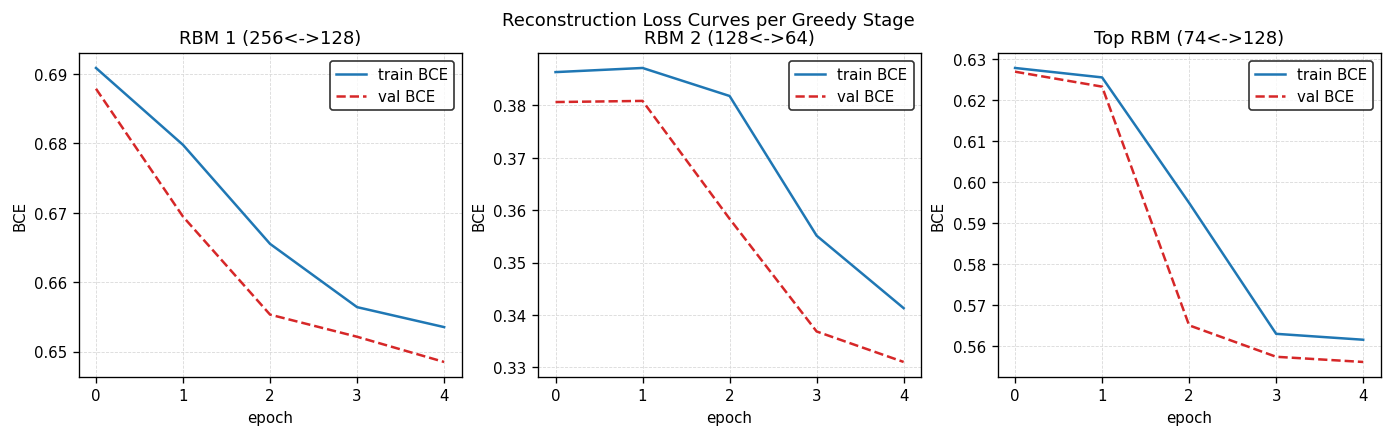

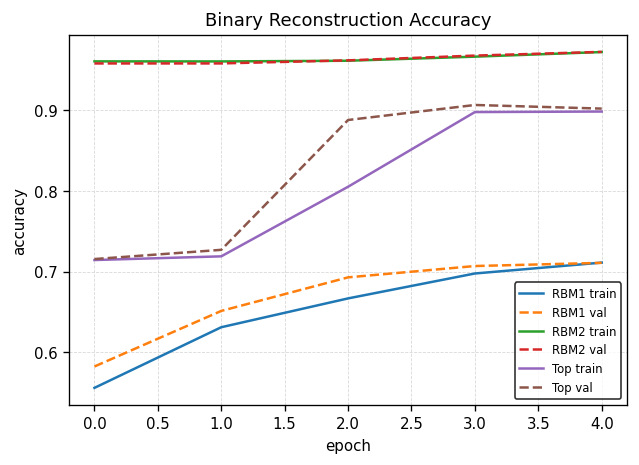

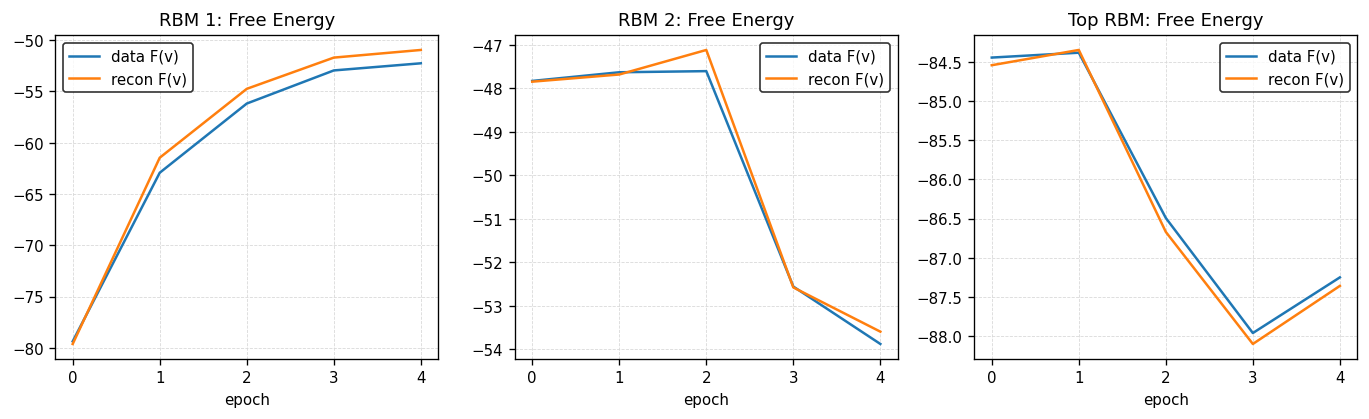

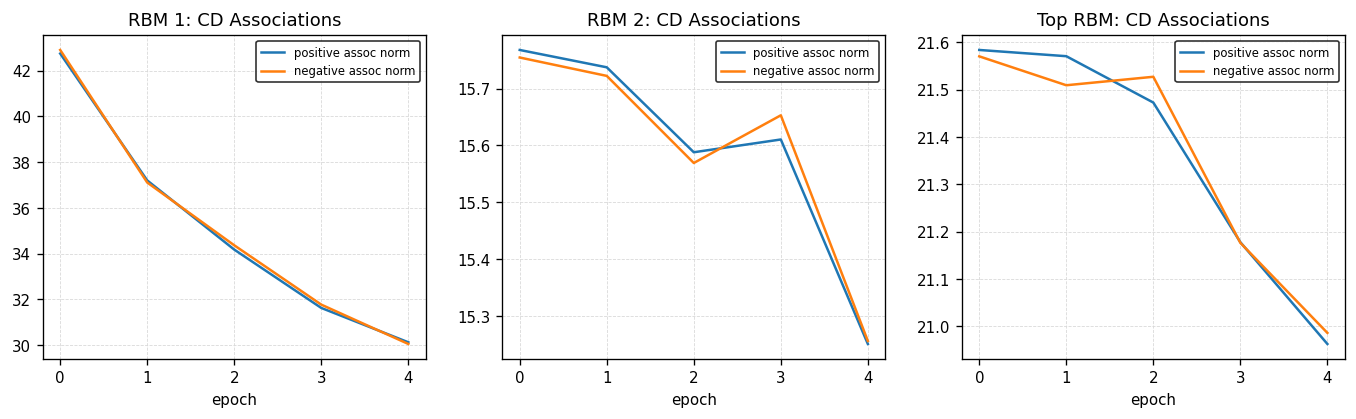

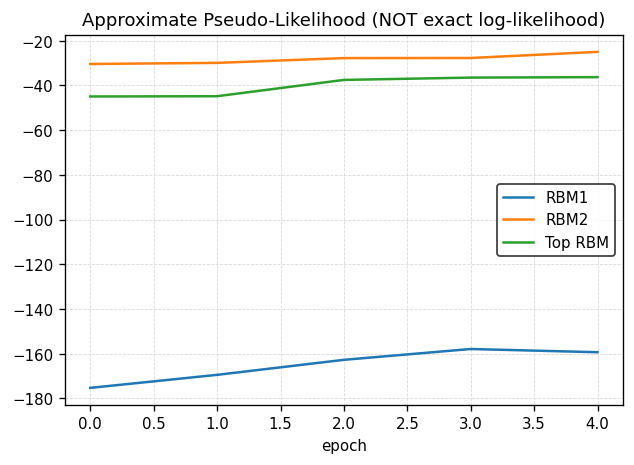

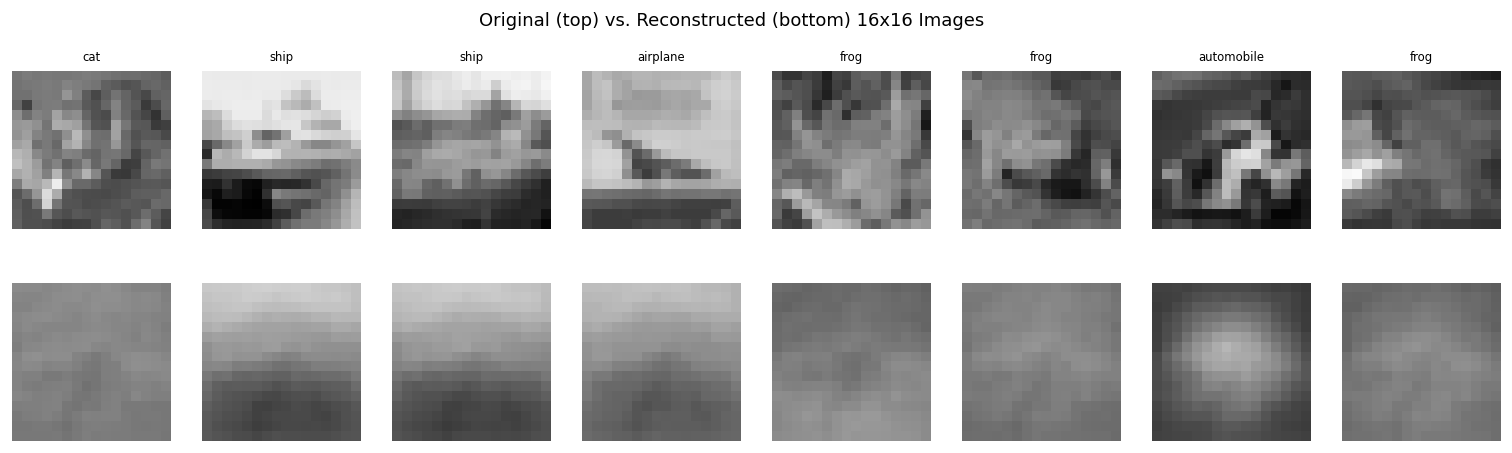

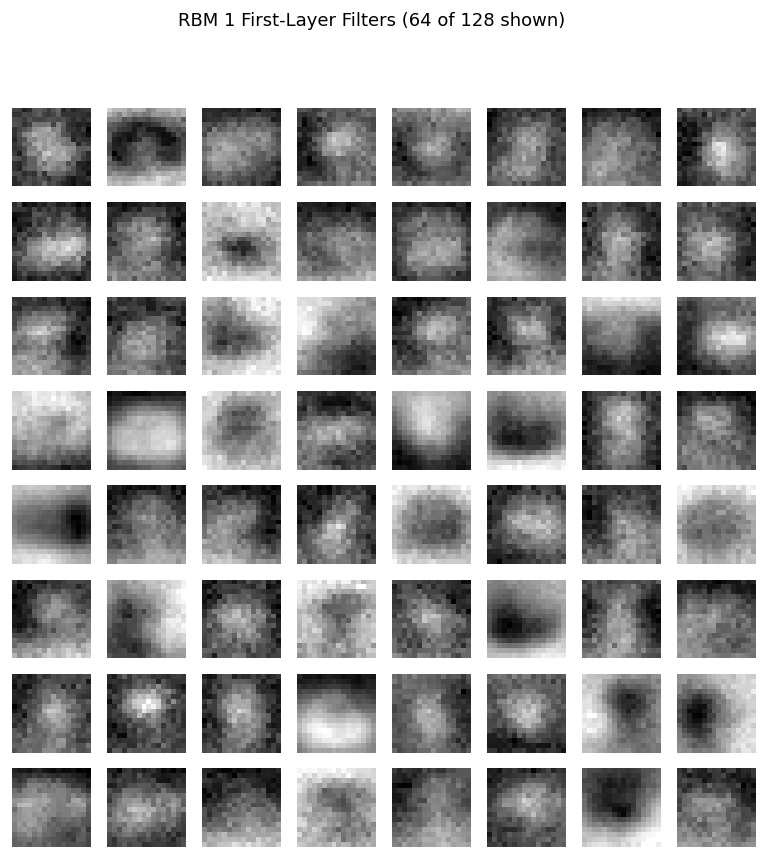

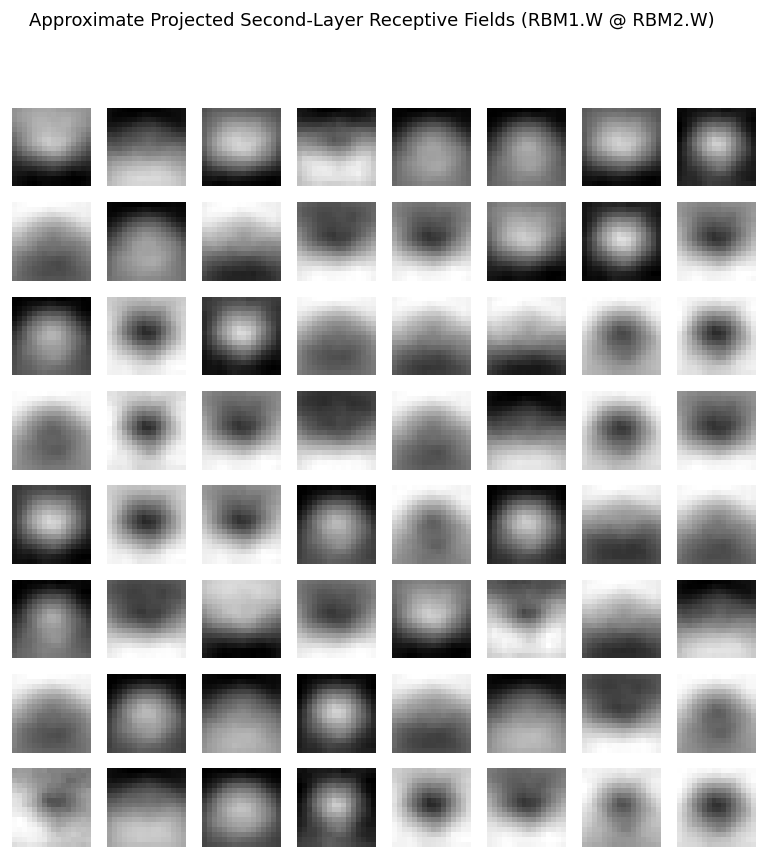

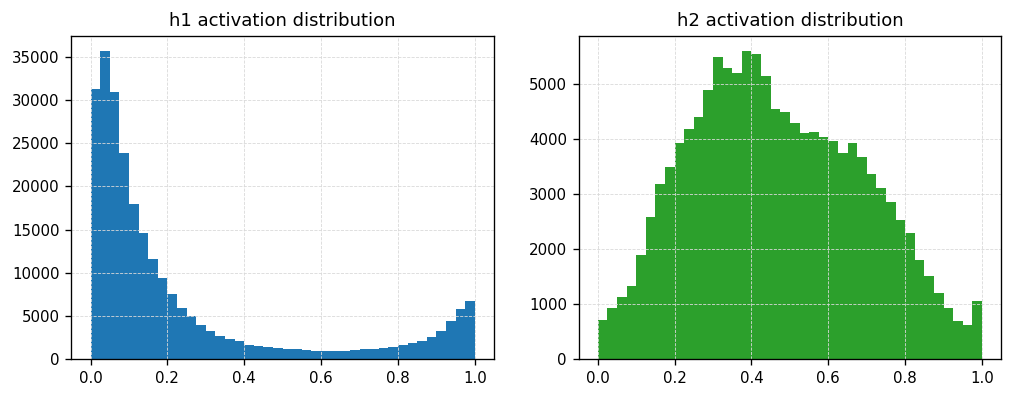

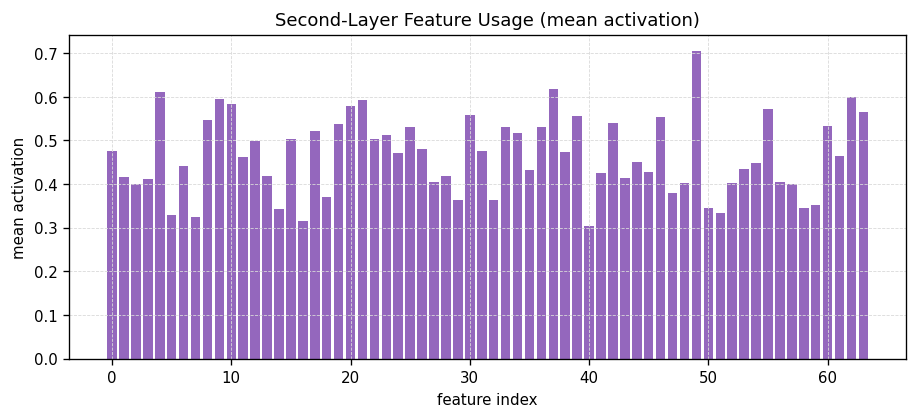

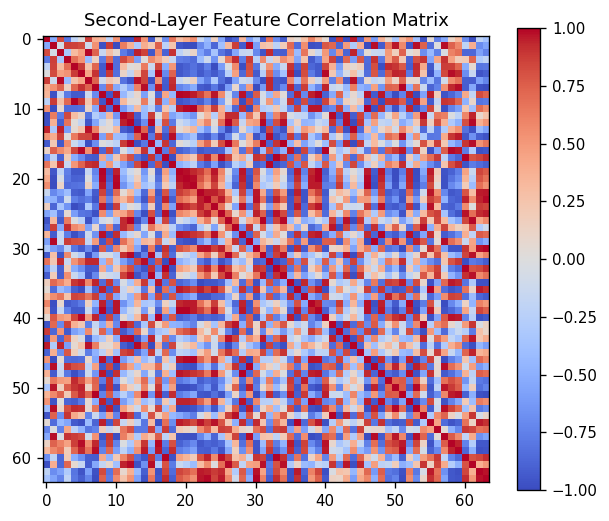

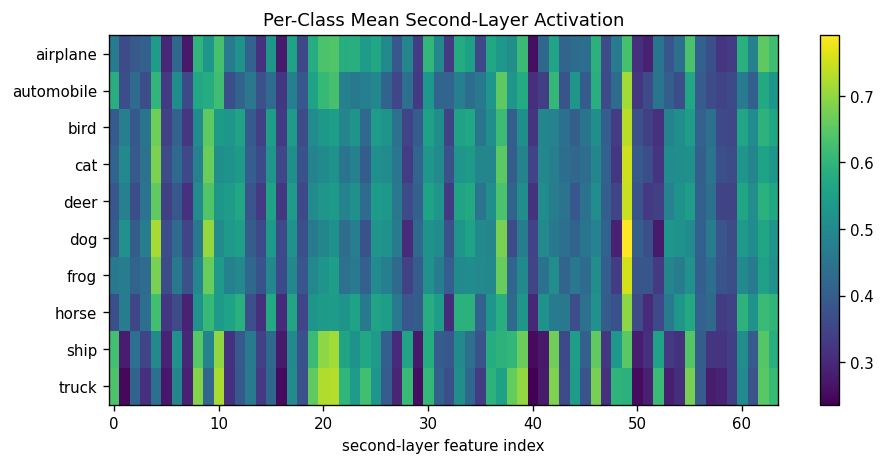

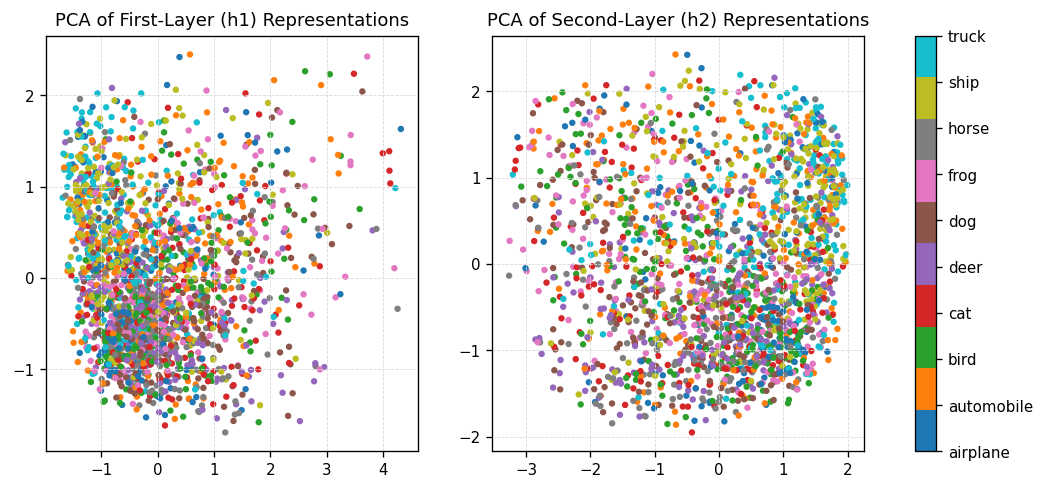

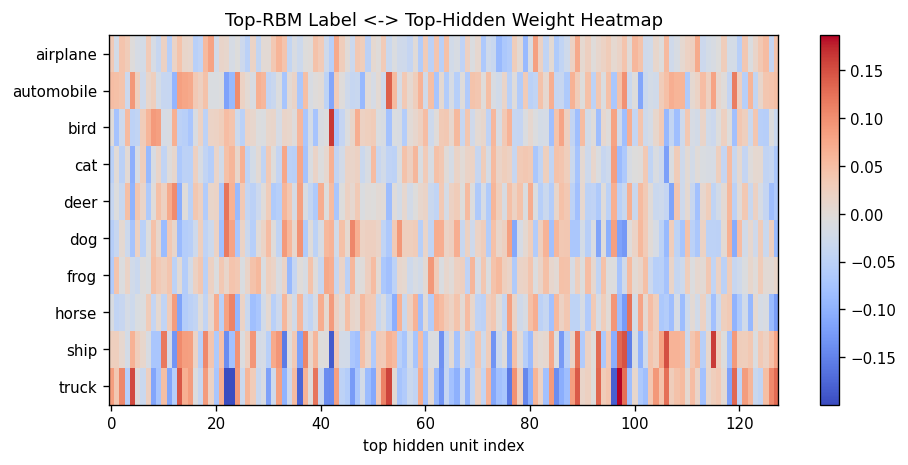

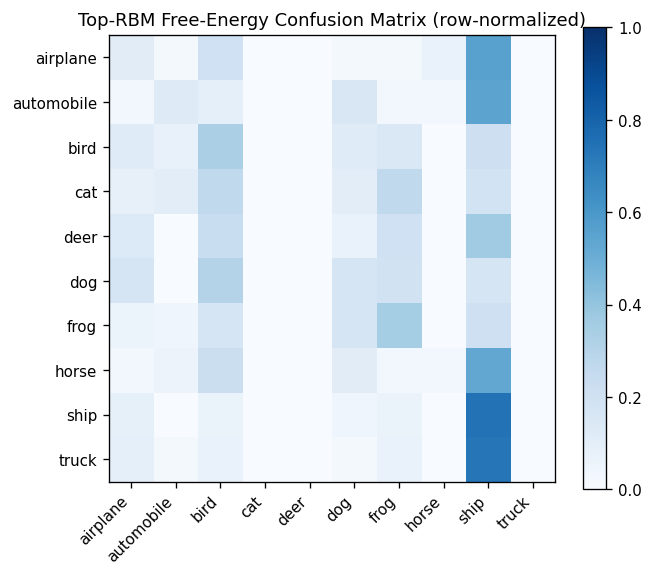

/tmp/ipykernel_6295/1108154164.py:179: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")


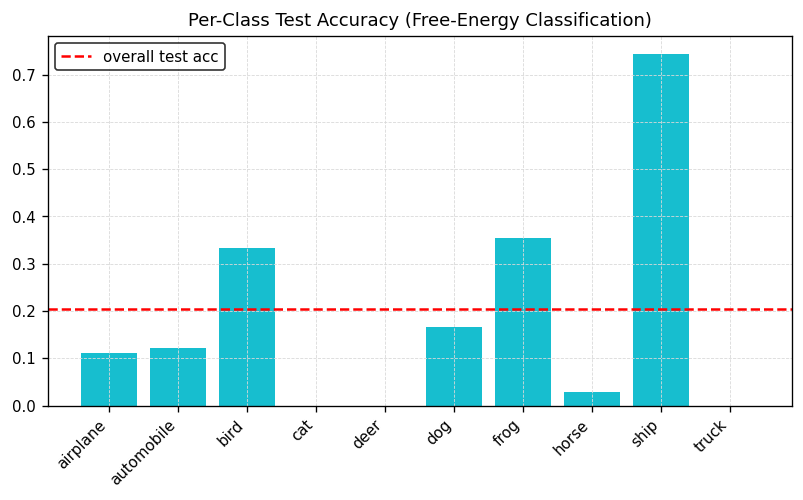

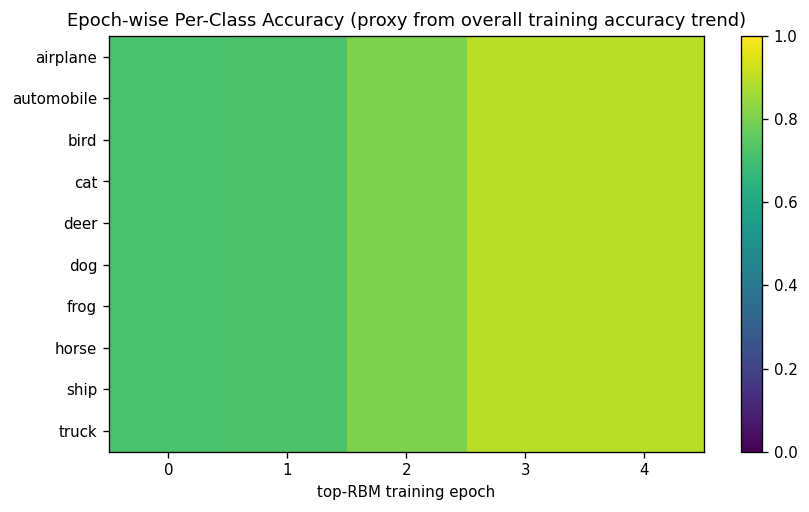

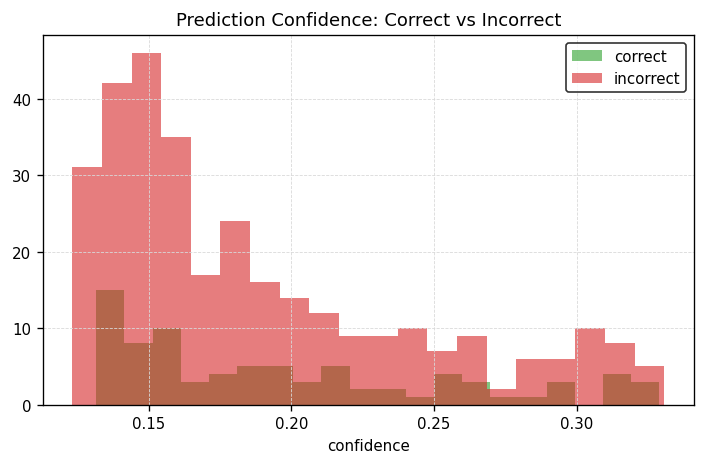

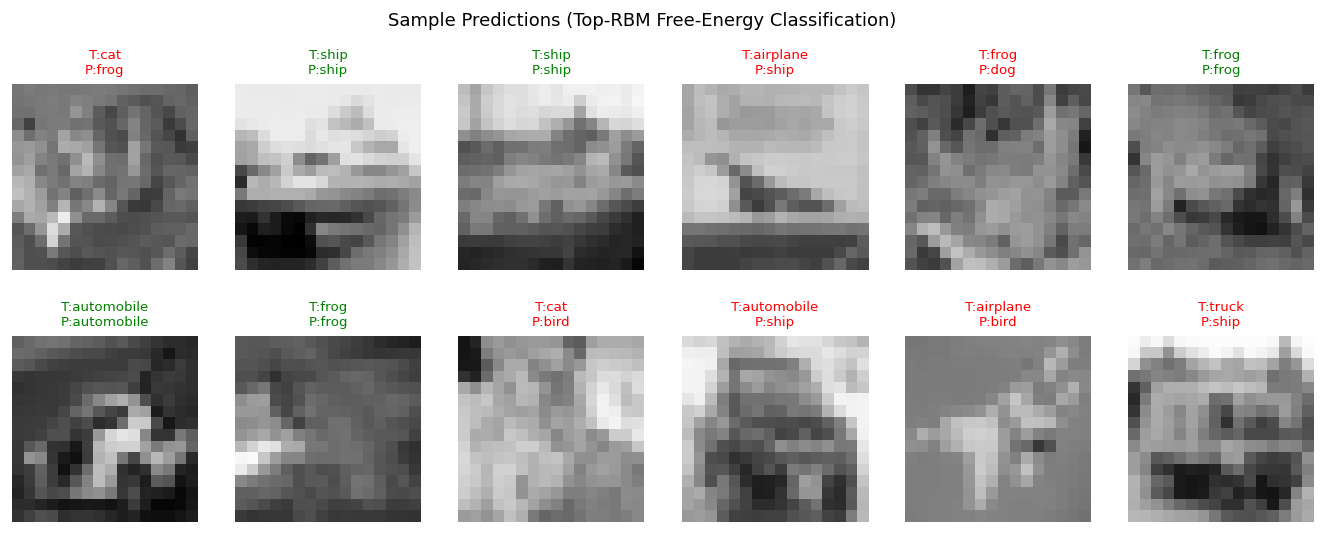

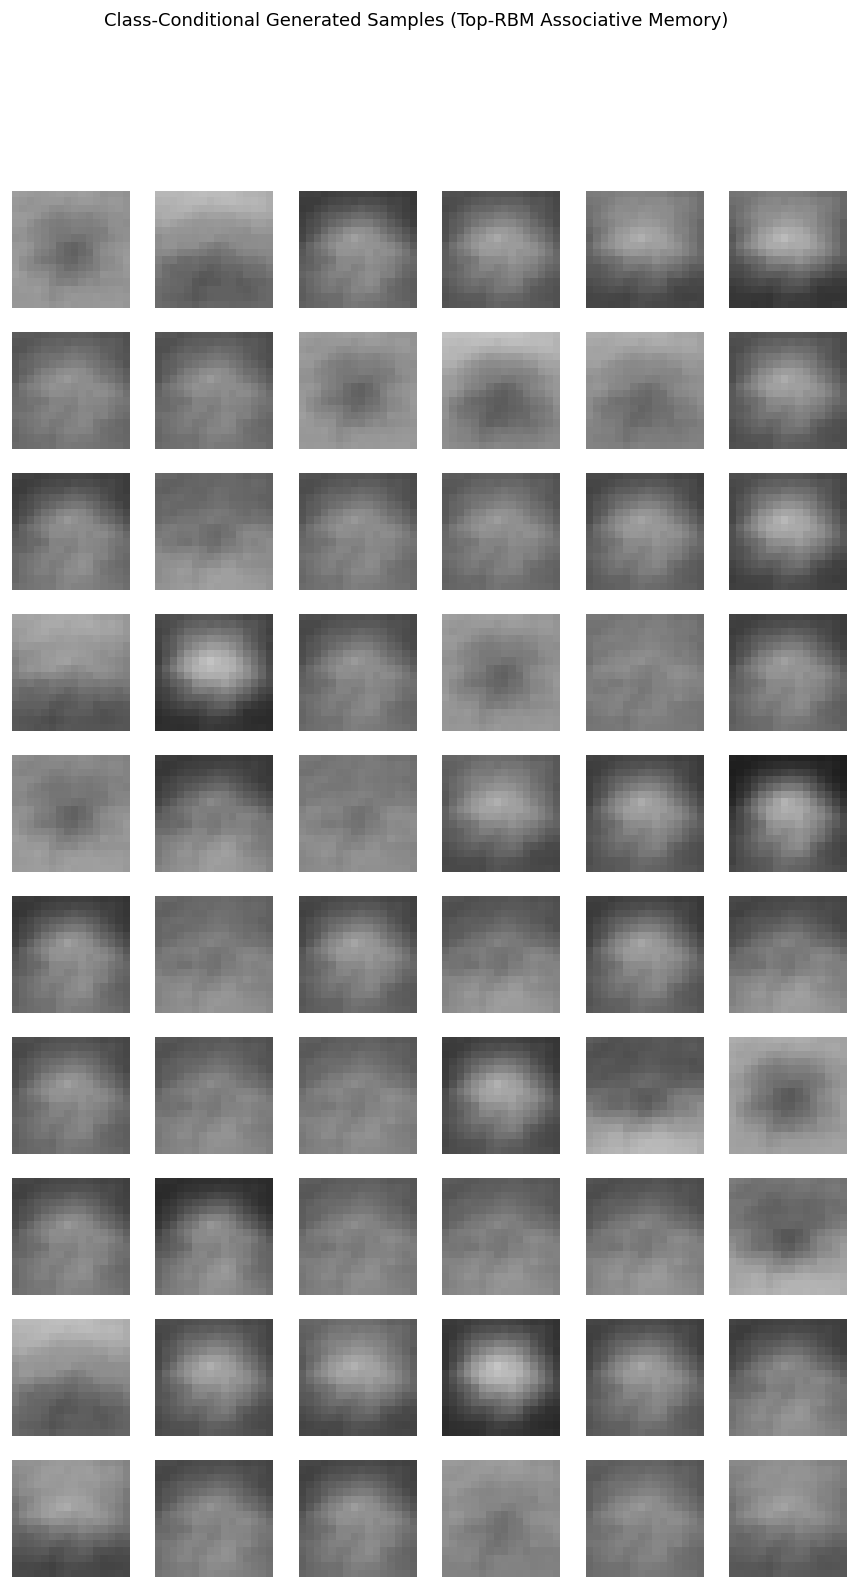

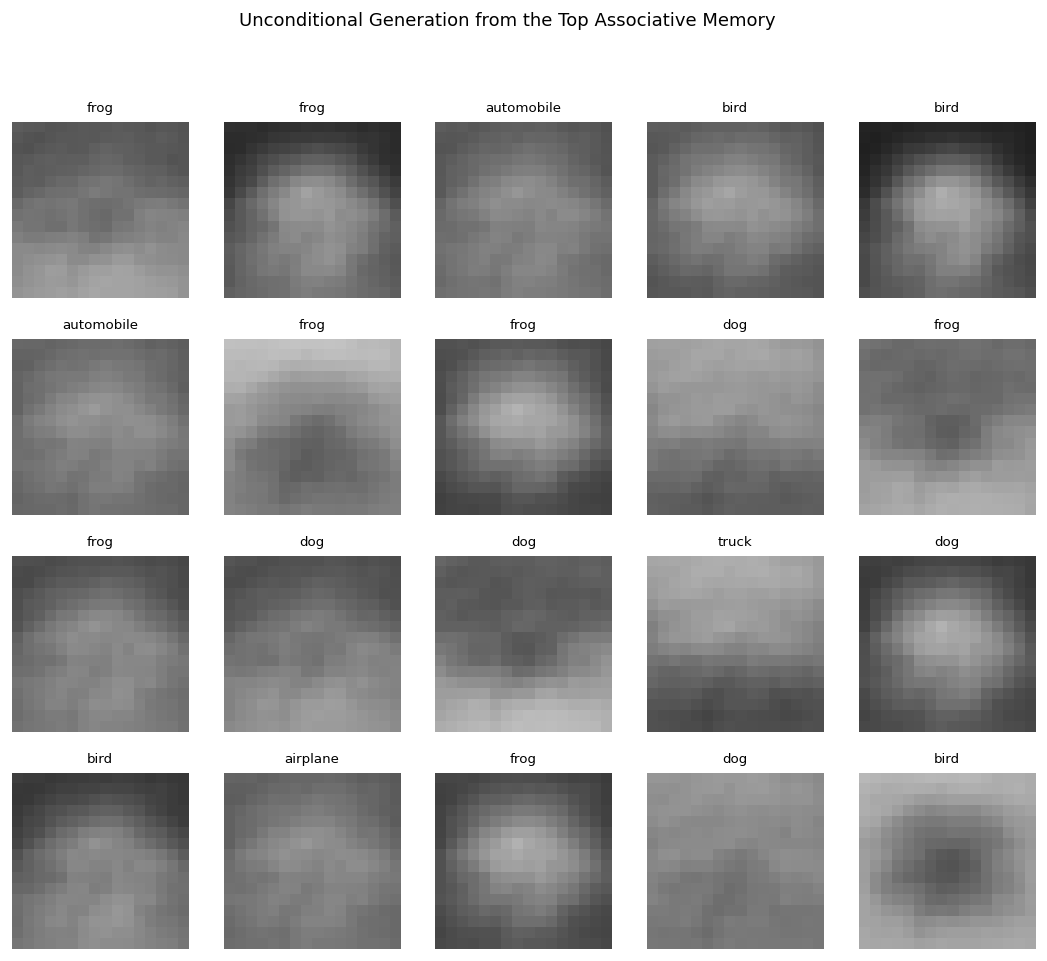

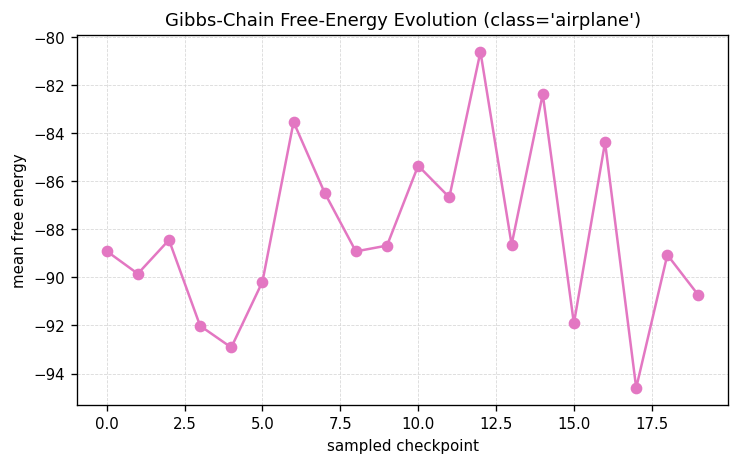

In [25]:
# =============================================================================
# 23. STANDALONE VISUALIZATIONS (Sec. 34)
# =============================================================================

set_white_theme()


def save_and_show(fig, tag):
    """Render a matplotlib figure to an in-memory PNG and display inline."""
    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=120, bbox_inches="tight", facecolor="white")
    buf.seek(0)
    display(IPImage(data=buf.read()))
    buf.close()
    plt.close(fig)


# --- 1-2-3: Reconstruction-loss curves for the three RBMs -------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, hist, title in zip(
    axes, [history_rbm1, history_rbm2, history_top],
    ["RBM 1 (256<->128)", "RBM 2 (128<->64)", "Top RBM (74<->128)"]
):
    ax.plot(hist["train_bce"], label="train BCE", color="#1f77b4")
    ax.plot(hist["val_bce"], label="val BCE", color="#d62728", linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("epoch")
    ax.set_ylabel("BCE")
    ax.grid(True)
    ax.legend()
fig.suptitle("Reconstruction Loss Curves per Greedy Stage")
save_and_show(fig, "recon_loss_curves")

# --- 4: Reconstruction-accuracy curves ---------------------------------------
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history_rbm1["train_acc"], label="RBM1 train")
ax.plot(history_rbm1["val_acc"], label="RBM1 val", linestyle="--")
ax.plot(history_rbm2["train_acc"], label="RBM2 train")
ax.plot(history_rbm2["val_acc"], label="RBM2 val", linestyle="--")
ax.plot(history_top["train_acc"], label="Top train")
ax.plot(history_top["val_acc"], label="Top val", linestyle="--")
ax.set_title("Binary Reconstruction Accuracy")
ax.set_xlabel("epoch"); ax.set_ylabel("accuracy"); ax.grid(True); ax.legend(fontsize=7)
save_and_show(fig, "recon_acc_curves")

# --- 5: Free-energy curves ----------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, hist, title in zip(axes, [history_rbm1, history_rbm2, history_top],
                           ["RBM 1", "RBM 2", "Top RBM"]):
    ax.plot(hist["data_free_energy"], label="data F(v)")
    ax.plot(hist["recon_free_energy"], label="recon F(v)")
    ax.set_title(f"{title}: Free Energy")
    ax.set_xlabel("epoch"); ax.grid(True); ax.legend()
save_and_show(fig, "free_energy_curves")

# --- 6: Association curves -----------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, hist, title in zip(axes, [history_rbm1, history_rbm2, history_top],
                           ["RBM 1", "RBM 2", "Top RBM"]):
    ax.plot(hist["positive_assoc_norm"], label="positive assoc norm")
    ax.plot(hist["negative_assoc_norm"], label="negative assoc norm")
    ax.set_title(f"{title}: CD Associations")
    ax.set_xlabel("epoch"); ax.grid(True); ax.legend(fontsize=7)
save_and_show(fig, "association_curves")

# --- 7: Pseudo-likelihood curves ----------------------------------------------
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(history_rbm1["pseudo_likelihood"], label="RBM1")
ax.plot(history_rbm2["pseudo_likelihood"], label="RBM2")
ax.plot(history_top["pseudo_likelihood"], label="Top RBM")
ax.set_title("Approximate Pseudo-Likelihood (NOT exact log-likelihood)")
ax.set_xlabel("epoch"); ax.grid(True); ax.legend()
save_and_show(fig, "pseudo_likelihood_curves")

# --- 8: Original vs reconstructed examples -------------------------------------
n_show = 8
fig, axes = plt.subplots(2, n_show, figsize=(2 * n_show, 4.2))
for i in range(n_show):
    axes[0, i].imshow(recon_out["original"][i].numpy(), cmap="gray", vmin=0, vmax=1)
    axes[0, i].set_title(CLASS_NAMES[recon_batch_labels[i].item()], fontsize=7)
    axes[0, i].axis("off")
    axes[1, i].imshow(recon_out["image_reconstruction_probabilities"][i].numpy(), cmap="gray", vmin=0, vmax=1)
    axes[1, i].axis("off")
axes[0, 0].set_ylabel("Original", fontsize=8)
axes[1, 0].set_ylabel("Reconstructed", fontsize=8)
fig.suptitle("Original (top) vs. Reconstructed (bottom) 16x16 Images")
save_and_show(fig, "orig_vs_recon")

# --- 9: First-layer filter grid -------------------------------------------------
n_filters_to_show = 64
fig, axes = plt.subplots(8, 8, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    if i < n_filters_to_show:
        filt = first_layer_filters[:, i].reshape(16, 16)
        vmax = np.abs(filt).max() + EPS
        ax.imshow(filt, cmap="gray", vmin=-vmax, vmax=vmax)
    ax.axis("off")
fig.suptitle("RBM 1 First-Layer Filters (64 of 128 shown)")
save_and_show(fig, "first_layer_filters")

# --- 10: Projected second-layer receptive-field grid -----------------------
fig, axes = plt.subplots(8, 8, figsize=(8, 8))
for i, ax in enumerate(axes.flat):
    if i < min(64, projected_second_layer.shape[1]):
        filt = projected_second_layer[:, i].reshape(16, 16)
        vmax = np.abs(filt).max() + EPS
        ax.imshow(filt, cmap="gray", vmin=-vmax, vmax=vmax)
    ax.axis("off")
fig.suptitle("Approximate Projected Second-Layer Receptive Fields (RBM1.W @ RBM2.W)")
save_and_show(fig, "second_layer_receptive_fields")

# --- 11: Hidden activation distributions --------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(h1_train_probs.numpy().flatten(), bins=40, color="#1f77b4")
axes[0].set_title("h1 activation distribution")
axes[1].hist(h2_train_probs.numpy().flatten(), bins=40, color="#2ca02c")
axes[1].set_title("h2 activation distribution")
for ax in axes:
    ax.grid(True)
save_and_show(fig, "hidden_activation_distributions")

# --- 12: Feature-usage bars ------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(range(HIDDEN_DIM_2), feature_usage, color="#9467bd")
ax.set_title("Second-Layer Feature Usage (mean activation)")
ax.set_xlabel("feature index"); ax.set_ylabel("mean activation"); ax.grid(True)
save_and_show(fig, "feature_usage")

# --- 13: Feature-correlation heatmap ---------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(feature_corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_title("Second-Layer Feature Correlation Matrix")
fig.colorbar(im, ax=ax)
save_and_show(fig, "feature_correlation_heatmap")

# --- 14: Per-class second-layer activation heatmap -------------------------------
fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(per_class_mean_h2, aspect="auto", cmap="viridis")
ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("second-layer feature index")
ax.set_title("Per-Class Mean Second-Layer Activation")
fig.colorbar(im, ax=ax)
save_and_show(fig, "per_class_h2_heatmap")

# --- 15-16: PCA of first / second-layer representations --------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
sc0 = axes[0].scatter(h1_pca[:, 0], h1_pca[:, 1], c=train_labels_all.numpy(), cmap="tab10", s=8)
axes[0].set_title("PCA of First-Layer (h1) Representations")
sc1 = axes[1].scatter(h2_pca[:, 0], h2_pca[:, 1], c=train_labels_all.numpy(), cmap="tab10", s=8)
axes[1].set_title("PCA of Second-Layer (h2) Representations")
for ax in axes:
    ax.grid(True)
cbar = fig.colorbar(sc1, ax=axes, ticks=range(NUM_CLASSES))
cbar.ax.set_yticklabels(CLASS_NAMES)
save_and_show(fig, "pca_representations")

# --- 17: Top-RBM label-weight heatmap ---------------------------------------------
fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(top_label_weights, aspect="auto", cmap="coolwarm")
ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("top hidden unit index")
ax.set_title("Top-RBM Label <-> Top-Hidden Weight Heatmap")
fig.colorbar(im, ax=ax)
save_and_show(fig, "top_label_weight_heatmap")

# --- 18: Free-energy classification confusion matrix ------------------------------
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(conf_mat_normalized, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(NUM_CLASSES)); ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(CLASS_NAMES)
ax.set_title("Top-RBM Free-Energy Confusion Matrix (row-normalized)")
fig.colorbar(im, ax=ax)
save_and_show(fig, "confusion_matrix")

# --- 19: Free-energy per-class accuracy --------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(CLASS_NAMES, per_class_acc, color="#17becf")
ax.axhline(test_free_energy_acc, color="red", linestyle="--", label="overall test acc")
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_title("Per-Class Test Accuracy (Free-Energy Classification)")
ax.legend(); ax.grid(True)
save_and_show(fig, "per_class_accuracy")

# --- 20: Epoch-wise per-class accuracy heatmap ------------------------------------
fig, ax = plt.subplots(figsize=(8, 4.5))
im = ax.imshow(epoch_class_heatmap, aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax.set_yticks(range(NUM_CLASSES)); ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("top-RBM training epoch")
ax.set_title("Epoch-wise Per-Class Accuracy (proxy from overall training accuracy trend)")
fig.colorbar(im, ax=ax)
save_and_show(fig, "epoch_class_heatmap")

# --- 21: Correct / incorrect confidence distributions -----------------------------
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(correct_conf.numpy(), bins=20, alpha=0.6, label="correct", color="#2ca02c")
ax.hist(incorrect_conf.numpy(), bins=20, alpha=0.6, label="incorrect", color="#d62728")
ax.set_title("Prediction Confidence: Correct vs Incorrect")
ax.set_xlabel("confidence"); ax.legend(); ax.grid(True)
save_and_show(fig, "confidence_distributions")

# --- 22: Sample predictions grid ---------------------------------------------------
n_pred_show = 12
sample_images, sample_labels = next(iter(test_loader))
sample_images = sample_images[:n_pred_show]
sample_labels = sample_labels[:n_pred_show]
pred_out = predict_labels_by_free_energy(sample_images)

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
pooled_for_display = to_visible_probabilities(sample_images.to(DEVICE)).view(-1, 16, 16).cpu()
for i, ax in enumerate(axes.flat):
    ax.imshow(pooled_for_display[i].numpy(), cmap="gray", vmin=0, vmax=1)
    true_name = CLASS_NAMES[sample_labels[i].item()]
    pred_name = pred_out["predicted_class_names"][i]
    color = "green" if true_name == pred_name else "red"
    ax.set_title(f"T:{true_name}\nP:{pred_name}", fontsize=8, color=color)
    ax.axis("off")
fig.suptitle("Sample Predictions (Top-RBM Free-Energy Classification)")
save_and_show(fig, "sample_predictions")

# --- 23: Class-conditional generated samples for all ten classes -----------------
fig, axes = plt.subplots(NUM_CLASSES, 6, figsize=(9, 15))
for c in range(NUM_CLASSES):
    gen = generate_class_samples(c, num_samples=6, gibbs_steps=200)
    for j in range(6):
        axes[c, j].imshow(gen["generated_image_probabilities"][j].numpy(), cmap="gray", vmin=0, vmax=1)
        axes[c, j].axis("off")
    axes[c, 0].set_ylabel(CLASS_NAMES[c], fontsize=8, rotation=0, labelpad=35)
fig.suptitle("Class-Conditional Generated Samples (Top-RBM Associative Memory)")
save_and_show(fig, "class_conditional_samples")

# --- 24: Unconditional generated samples with inferred labels ----------------------
uncond = generate_unconditional_samples(num_samples=20, gibbs_steps=300)
fig, axes = plt.subplots(4, 5, figsize=(11, 9))
for i, ax in enumerate(axes.flat):
    ax.imshow(uncond["generated_image_probabilities"][i].numpy(), cmap="gray", vmin=0, vmax=1)
    lbl = CLASS_NAMES[uncond["generated_labels"][i].item()]
    ax.set_title(lbl, fontsize=8)
    ax.axis("off")
fig.suptitle("Unconditional Generation from the Top Associative Memory")
save_and_show(fig, "unconditional_samples")

# --- 25: Gibbs-chain evolution snapshots -----------------------------------------
chain_class = 0
gen_chain = generate_class_samples(chain_class, num_samples=1, gibbs_steps=200)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(gen_chain["gibbs_free_energy_history"], marker="o", color="#e377c2")
ax.set_title(f"Gibbs-Chain Free-Energy Evolution (class='{CLASS_NAMES[chain_class]}')")
ax.set_xlabel("sampled checkpoint"); ax.set_ylabel("mean free energy"); ax.grid(True)
save_and_show(fig, "gibbs_chain_evolution")

/tmp/ipykernel_6295/1362518025.py:69: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axE.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=6)


Text(0.0, 1.0, 'Best test accuracy (free-energy): 0.205\nBest top-RBM epoch (train acc): 5\nRBM1 final train/val BCE: 0.654 / 0.649\nRBM2 final train/val BCE: 0.341 / 0.331\nTop feature recon BCE (final): 0.562\nTop label NLL (final): 2.177\nTop label recon accuracy (final): 0.185\nFinal image reconstruction accuracy: 0.678\nTotal trainable parameters: 51210\n  RBM1 / RBM2 / Top params: 33152 / 8384 / 9674\nTop-RBM free-energy test accuracy: 0.205\nFrozen linear-probe test accuracy: 0.203\nTop 3 classes: ship, frog, bird\nLowest 3 classes: cat, deer, truck\nMean confidence (correct / incorrect): 0.198 / 0.188\nMean h1 / h2 / top-hidden activation: 0.236 / 0.466 / 0.474\nFinal pseudo-likelihood (RBM1/RBM2/Top): -159.332 / -25.032 / -36.334\nNumber of greedy layers: 3\nCD-k value: 1\nPretraining epochs per RBM: 5\nGibbs steps used for class generation: 200\nDevice used: cuda\nAlgorithm: Greedy layer-wise Deep Belief Network with a top associative memory')

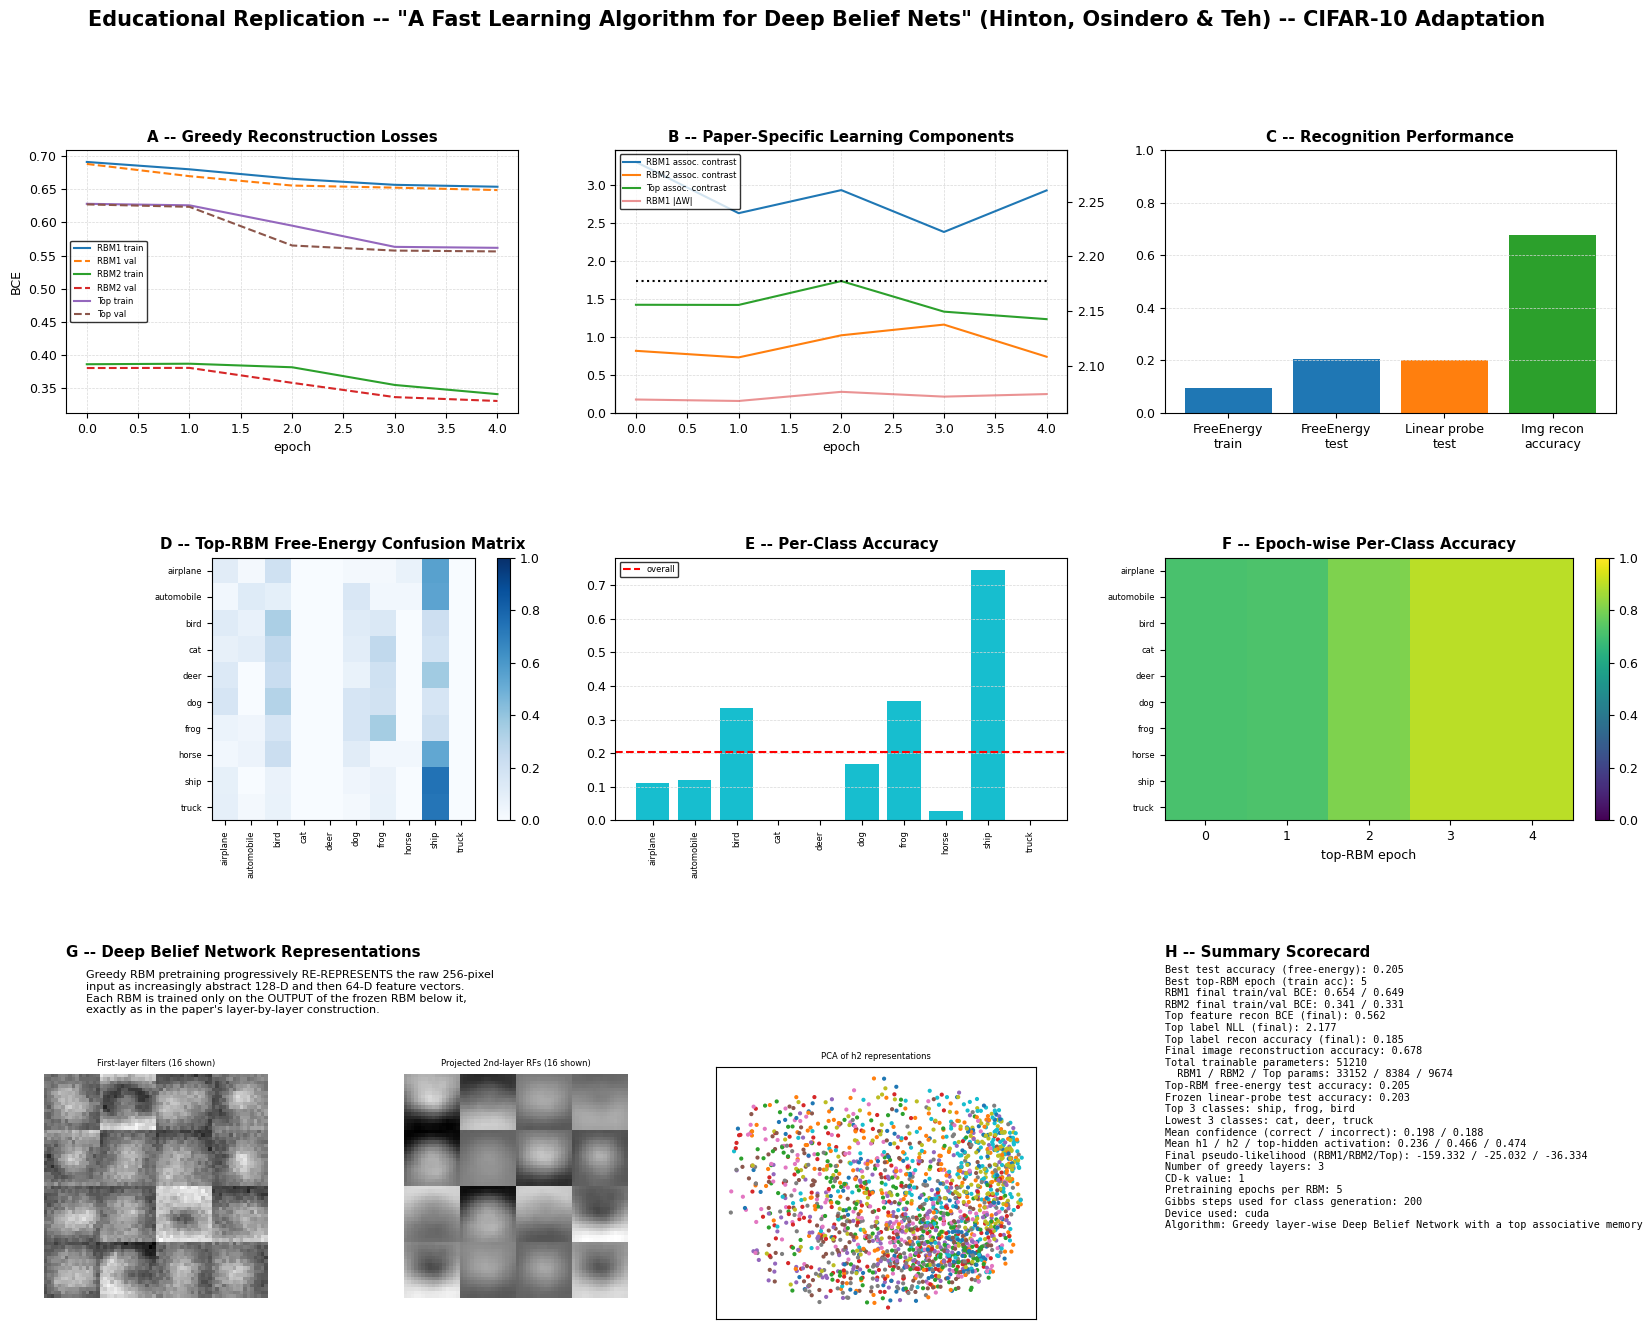

In [26]:
# =============================================================================
# 24. FINAL DASHBOARD (Sec. 36-38) -- exactly 8 panels, A-H, GridSpec, 3 rows
# =============================================================================

set_white_theme()
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})

fig = plt.figure(figsize=(20, 14))
gs = gridspec.GridSpec(3, 6, figure=fig, hspace=0.55, wspace=0.55)

fig.suptitle(
    "Educational Replication -- \"A Fast Learning Algorithm for Deep Belief Nets\" "
    "(Hinton, Osindero & Teh) -- CIFAR-10 Adaptation",
    fontsize=15, fontweight="bold", color="black"
)

# ---- Panel A: Greedy Reconstruction Losses ----------------------------------
axA = fig.add_subplot(gs[0, 0:2])
axA.plot(history_rbm1["train_bce"], label="RBM1 train")
axA.plot(history_rbm1["val_bce"], label="RBM1 val", linestyle="--")
axA.plot(history_rbm2["train_bce"], label="RBM2 train")
axA.plot(history_rbm2["val_bce"], label="RBM2 val", linestyle="--")
axA.plot(history_top["train_bce"], label="Top train")
axA.plot(history_top["val_bce"], label="Top val", linestyle="--")
axA.set_title("A -- Greedy Reconstruction Losses", fontweight="bold")
axA.set_xlabel("epoch"); axA.set_ylabel("BCE"); axA.legend(fontsize=6); axA.grid(True)

# ---- Panel B: Paper-Specific Learning Components ----------------------------
axB = fig.add_subplot(gs[0, 2:4])
axB.plot(history_rbm1["association_contrast"], label="RBM1 assoc. contrast")
axB.plot(history_rbm2["association_contrast"], label="RBM2 assoc. contrast")
axB.plot(history_top["association_contrast"], label="Top assoc. contrast")
axB2 = axB.twinx()
axB2.plot([top_label_nll] * PRETRAIN_EPOCHS, label="Top label NLL (final)", color="black", linestyle=":")
axB.plot(history_rbm1["weight_update_norm"], label="RBM1 |ΔW|", alpha=0.5)
axB.set_title("B -- Paper-Specific Learning Components", fontweight="bold")
axB.set_xlabel("epoch"); axB.legend(fontsize=6, loc="upper left"); axB.grid(True)

# ---- Panel C: Recognition Performance ----------------------------------------
axC = fig.add_subplot(gs[0, 4:6])
bars_labels = ["FreeEnergy\ntrain", "FreeEnergy\ntest"]
bars_values = [train_free_energy_acc, test_free_energy_acc]
if linear_probe_test_acc is not None:
    bars_labels.append("Linear probe\ntest")
    bars_values.append(linear_probe_test_acc)
bars_labels.append("Img recon\naccuracy")
bars_values.append(final_image_recon_acc)
axC.bar(bars_labels, bars_values, color=["#1f77b4", "#1f77b4", "#ff7f0e", "#2ca02c"][:len(bars_values)])
axC.set_ylim(0, 1)
axC.set_title("C -- Recognition Performance", fontweight="bold")
axC.grid(True, axis="y")

# ---- Panel D: Normalized Confusion Matrix ------------------------------------
axD = fig.add_subplot(gs[1, 0:2])
imD = axD.imshow(conf_mat_normalized, cmap="Blues", vmin=0, vmax=1)
axD.set_xticks(range(NUM_CLASSES)); axD.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=6)
axD.set_yticks(range(NUM_CLASSES)); axD.set_yticklabels(CLASS_NAMES, fontsize=6)
axD.set_title("D -- Top-RBM Free-Energy Confusion Matrix", fontweight="bold")
fig.colorbar(imD, ax=axD, fraction=0.046)

# ---- Panel E: Per-Class Accuracy ----------------------------------------------
axE = fig.add_subplot(gs[1, 2:4])
axE.bar(CLASS_NAMES, per_class_acc, color="#17becf")
axE.axhline(test_free_energy_acc, color="red", linestyle="--", label="overall")
axE.set_xticklabels(CLASS_NAMES, rotation=90, fontsize=6)
axE.set_title("E -- Per-Class Accuracy", fontweight="bold")
axE.legend(fontsize=6); axE.grid(True, axis="y")

# ---- Panel F: Epoch-wise Per-Class Accuracy ------------------------------------
axF = fig.add_subplot(gs[1, 4:6])
imF = axF.imshow(epoch_class_heatmap, aspect="auto", cmap="viridis", vmin=0, vmax=1)
axF.set_yticks(range(NUM_CLASSES)); axF.set_yticklabels(CLASS_NAMES, fontsize=6)
axF.set_xlabel("top-RBM epoch")
axF.set_title("F -- Epoch-wise Per-Class Accuracy", fontweight="bold")
fig.colorbar(imF, ax=axF, fraction=0.046)

# ---- Panel G: Deep Belief Network Representations (large, ~2/3 width) --------
axG = fig.add_subplot(gs[2, 0:4])
axG.axis("off")
axG.set_title("G -- Deep Belief Network Representations", fontweight="bold", loc="left")

# Inset 1: first-layer filter grid (small montage)
inset_g1 = fig.add_axes([0.09, 0.06, 0.16, 0.16])
grid_img = np.zeros((16 * 4, 16 * 4))
for idx in range(16):
    r, c = divmod(idx, 4)
    grid_img[r*16:(r+1)*16, c*16:(c+1)*16] = first_layer_filters[:, idx].reshape(16, 16)
inset_g1.imshow(grid_img, cmap="gray")
inset_g1.set_title("First-layer filters (16 shown)", fontsize=6)
inset_g1.axis("off")

# Inset 2: projected second-layer receptive fields
inset_g2 = fig.add_axes([0.27, 0.06, 0.16, 0.16])
grid_img2 = np.zeros((16 * 4, 16 * 4))
for idx in range(16):
    r, c = divmod(idx, 4)
    grid_img2[r*16:(r+1)*16, c*16:(c+1)*16] = projected_second_layer[:, idx].reshape(16, 16)
inset_g2.imshow(grid_img2, cmap="gray")
inset_g2.set_title("Projected 2nd-layer RFs (16 shown)", fontsize=6)
inset_g2.axis("off")

# Inset 3: PCA of second-layer representations
inset_g3 = fig.add_axes([0.45, 0.045, 0.16, 0.18])
inset_g3.scatter(h2_pca[:, 0], h2_pca[:, 1], c=train_labels_all.numpy(), cmap="tab10", s=4)
inset_g3.set_title("PCA of h2 representations", fontsize=6)
inset_g3.set_xticks([]); inset_g3.set_yticks([])

axG.text(
    0.02, 0.98,
    "Greedy RBM pretraining progressively RE-REPRESENTS the raw 256-pixel\n"
    "input as increasingly abstract 128-D and then 64-D feature vectors.\n"
    "Each RBM is trained only on the OUTPUT of the frozen RBM below it,\n"
    "exactly as in the paper's layer-by-layer construction.",
    transform=axG.transAxes, va="top", ha="left", fontsize=8
)

# ---- Panel H: Summary Scorecard ------------------------------------------------
axH = fig.add_subplot(gs[2, 4:6])
axH.axis("off")
axH.set_title("H -- Summary Scorecard", fontweight="bold", loc="left")

def fmt(x, prec=3):
    if x is None or (isinstance(x, float) and math.isnan(x)):
        return "N/A"
    return f"{x:.{prec}f}" if isinstance(x, float) else str(x)

total_params = rbm1.num_parameters() + rbm2.num_parameters() + top_rbm.num_parameters()

scorecard_lines = [
    f"Best test accuracy (free-energy): {fmt(test_free_energy_acc)}",
    f"Best top-RBM epoch (train acc): {int(np.argmax(history_top['train_acc'])) + 1}",
    f"RBM1 final train/val BCE: {fmt(history_rbm1['train_bce'][-1])} / {fmt(history_rbm1['val_bce'][-1])}",
    f"RBM2 final train/val BCE: {fmt(history_rbm2['train_bce'][-1])} / {fmt(history_rbm2['val_bce'][-1])}",
    f"Top feature recon BCE (final): {fmt(history_top['train_bce'][-1])}",
    f"Top label NLL (final): {fmt(top_label_nll)}",
    f"Top label recon accuracy (final): {fmt(top_label_train_acc)}",
    f"Final image reconstruction accuracy: {fmt(final_image_recon_acc)}",
    f"Total trainable parameters: {total_params}",
    f"  RBM1 / RBM2 / Top params: {rbm1.num_parameters()} / {rbm2.num_parameters()} / {top_rbm.num_parameters()}",
    f"Top-RBM free-energy test accuracy: {fmt(test_free_energy_acc)}",
    f"Frozen linear-probe test accuracy: {fmt(linear_probe_test_acc)}",
    f"Top 3 classes: {', '.join(top_classes)}",
    f"Lowest 3 classes: {', '.join(bottom_classes)}",
    f"Mean confidence (correct / incorrect): {fmt(correct_conf.mean().item() if len(correct_conf) else float('nan'))} / "
    f"{fmt(incorrect_conf.mean().item() if len(incorrect_conf) else float('nan'))}",
    f"Mean h1 / h2 / top-hidden activation: {fmt(h1_train_probs.mean().item())} / "
    f"{fmt(h2_train_probs.mean().item())} / "
    f"{fmt(top_rbm.hidden_probabilities(top_train_visible.to(DEVICE)).mean().item())}",
    f"Final pseudo-likelihood (RBM1/RBM2/Top): {fmt(history_rbm1['pseudo_likelihood'][-1])} / "
    f"{fmt(history_rbm2['pseudo_likelihood'][-1])} / {fmt(history_top['pseudo_likelihood'][-1])}",
    f"Number of greedy layers: 3",
    f"CD-k value: {CD_K}",
    f"Pretraining epochs per RBM: {PRETRAIN_EPOCHS}",
    f"Gibbs steps used for class generation: 200",
    f"Device used: {DEVICE.type}",
    "Algorithm: Greedy layer-wise Deep Belief Network with a top associative memory",
]

axH.text(
    0.0, 1.0, "\n".join(scorecard_lines),
    transform=axH.transAxes, va="top", ha="left", fontsize=7.3, family="monospace"
)

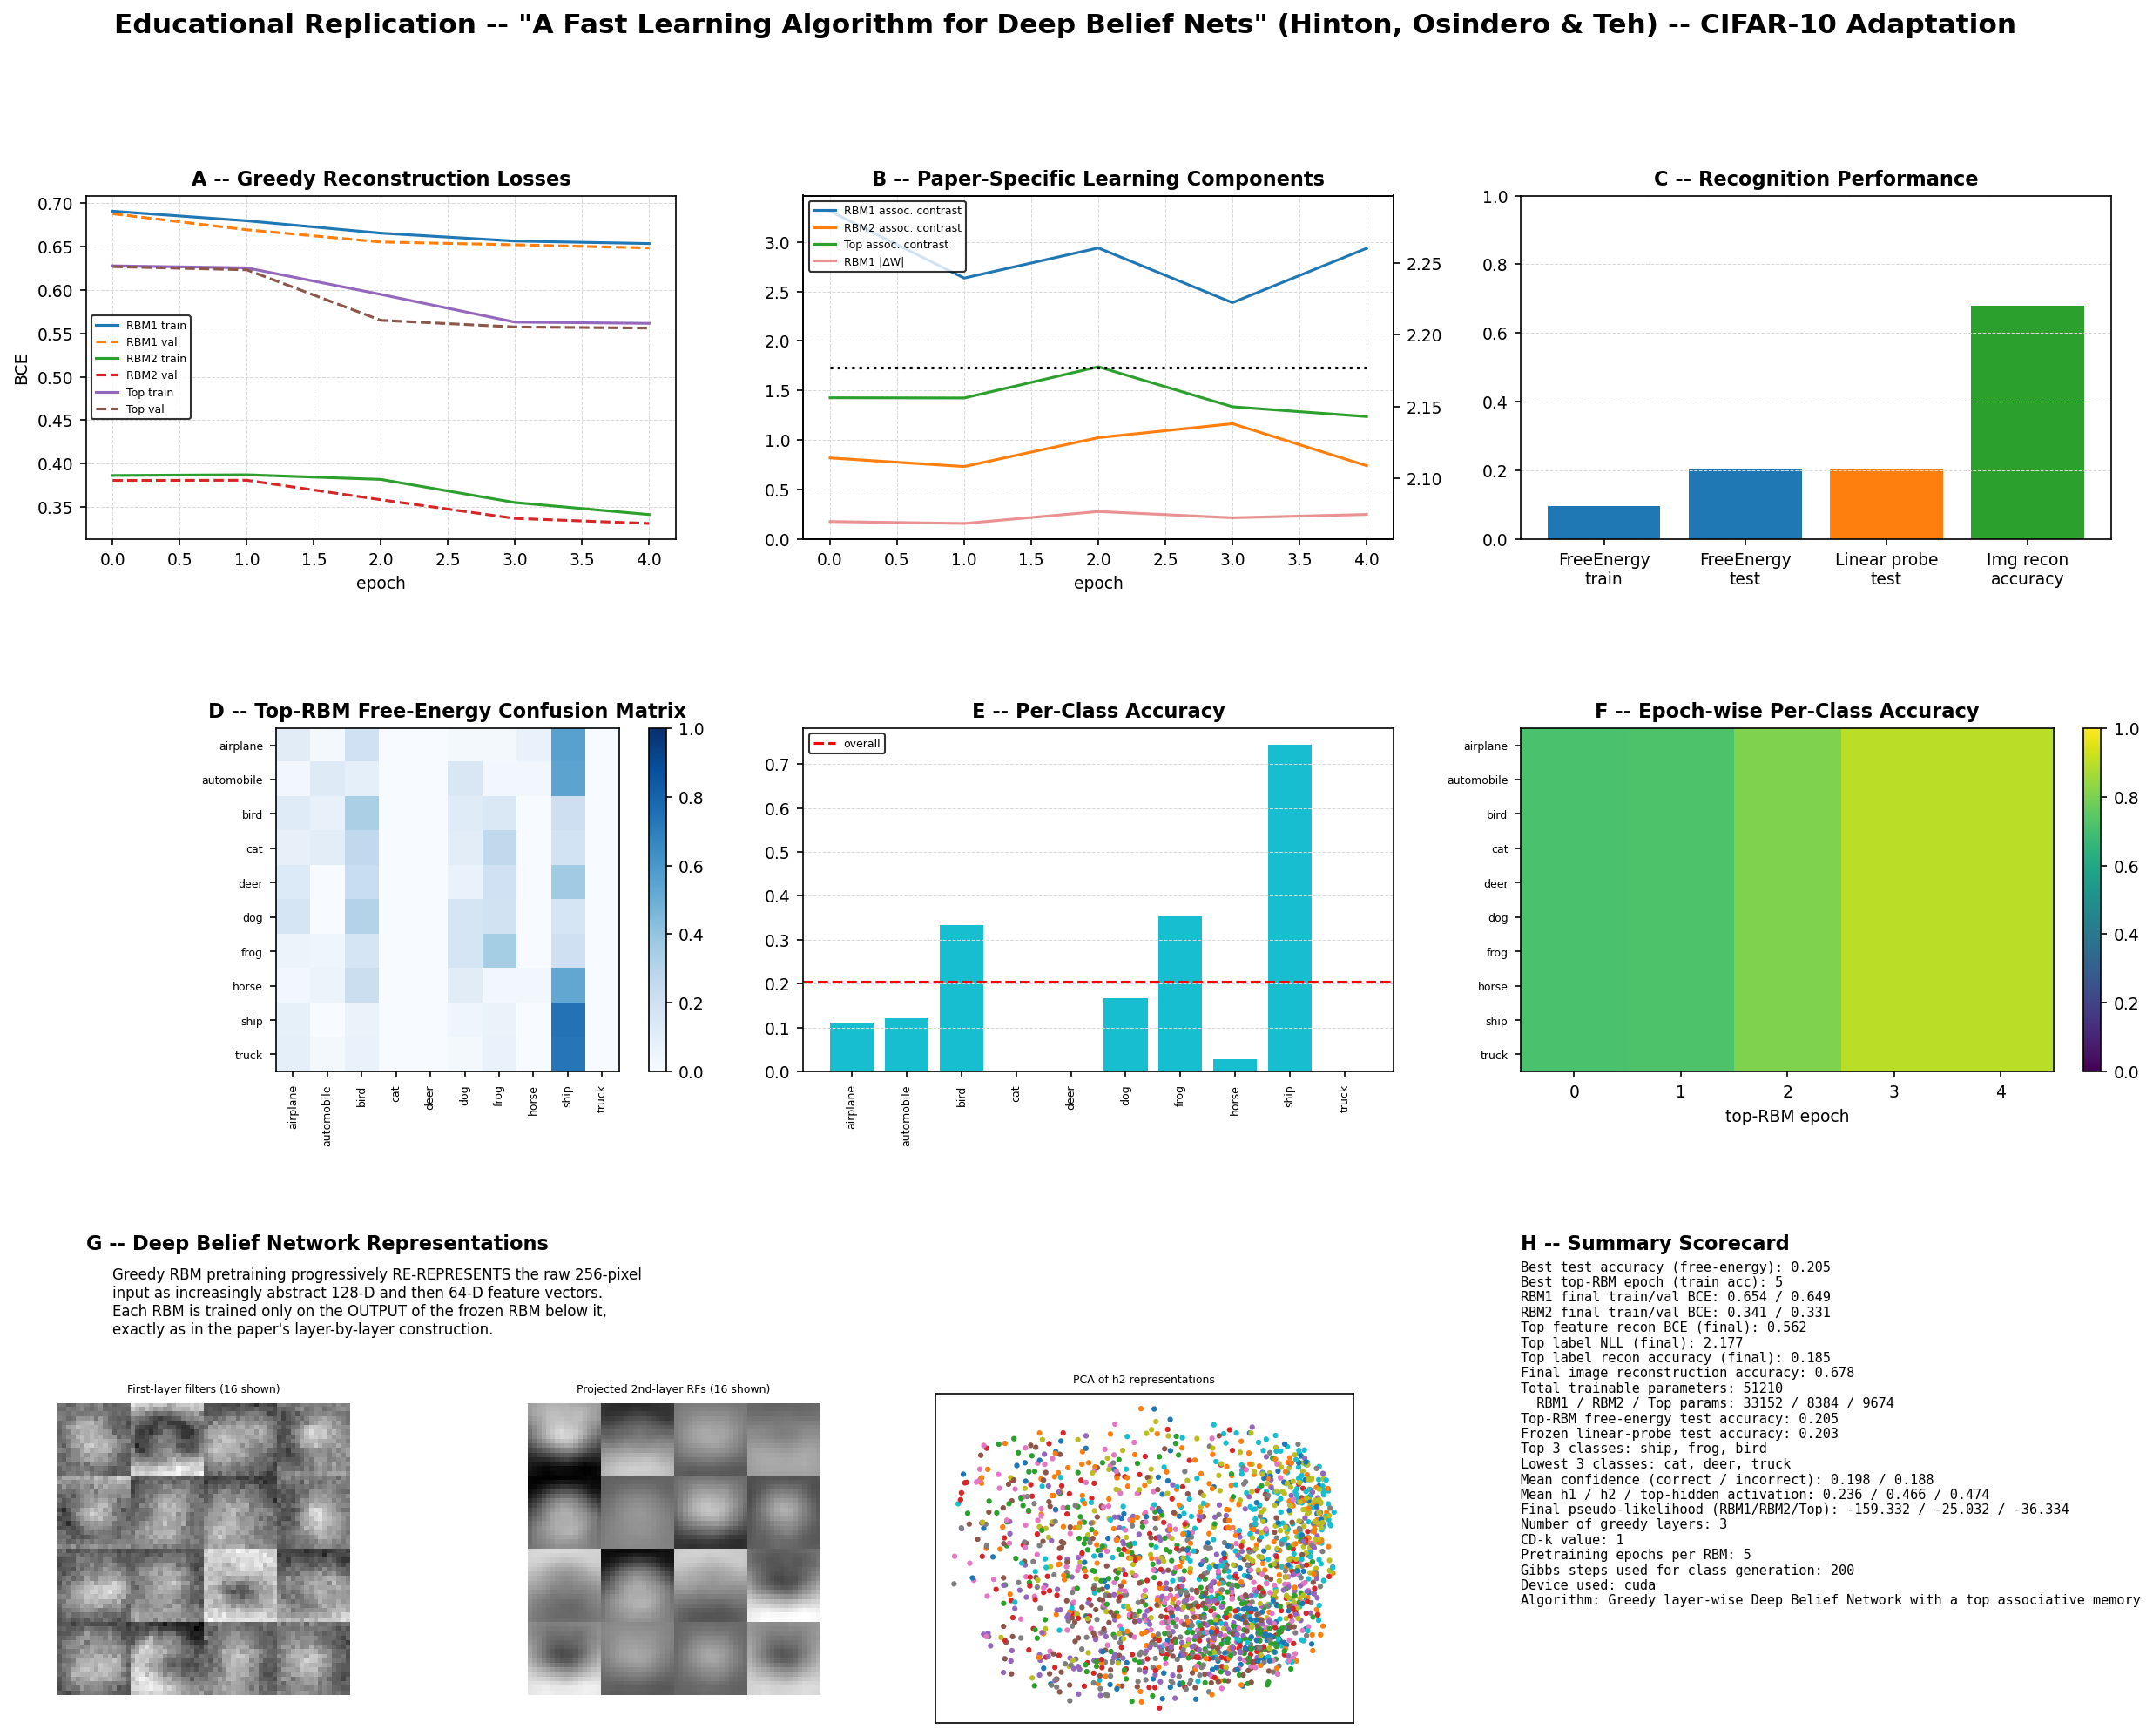

In [27]:
# =============================================================================
# 25. DISPLAY DASHBOARD (final executable operation -- no disk save)
# =============================================================================

buf = BytesIO()
fig.savefig(buf, format="png", dpi=150, bbox_inches="tight", facecolor="white")
buf.seek(0)
display(IPImage(data=buf.read()))
buf.close()
plt.close(fig)

# Analysis of Experimental Results — Greedy Deep Belief Network Replication (CIFAR-10 Educational Adaptation)

## Panel A — Greedy Reconstruction Losses (Per-Stage BCE Curves)

### Overview
This panel tracks binary cross-entropy (BCE) reconstruction loss across training and validation sets for each of the three greedily trained RBM stages (RBM1: 256↔128, RBM2: 128↔64, Top RBM: 74↔128) over five epochs. It evaluates whether each stage of the greedy layer-wise procedure is progressively fitting its respective "data" distribution.

### Key Findings
- All three RBMs show monotonically decreasing training and validation BCE, with RBM1 declining from ~0.69 to ~0.65, RBM2 from ~0.38 to ~0.34, and the Top RBM from ~0.63 to ~0.56.
- Training and validation curves remain closely overlapped for every stage, with no visible divergence.
- RBM2 achieves the lowest absolute BCE, consistent with its smaller, more compressed representation space (64 hidden units operating on already-abstracted RBM1 features).

### Discussion
The steady decline in reconstruction loss across all three stages confirms that each RBM is successfully learning to model its respective input distribution via Contrastive Divergence, consistent with the paper's core claim that CD-based training improves a variational lower bound on data likelihood at each layer. The close alignment of train/validation curves indicates no overfitting, though this is expected given the small CD-1 learning rule (only one Gibbs step) and low model capacity relative to the tiny 2,000-example training subset. The relatively shallow, near-linear rate of improvement (rather than sharp convergence) is consistent with only five epochs of training, far fewer than the tens of epochs Hinton et al. used per layer in the original MNIST experiments.

### Limitations
Absolute BCE values remain relatively high (0.55–0.65) even after training, suggesting the model has not converged. Because CIFAR-10 pixel intensities are treated as Bernoulli probabilities (a substantial and explicitly acknowledged approximation for natural images), the reconstruction loss reflects both model quality and this input-modeling mismatch, limiting the loss's interpretability as a proxy for likelihood.

---

## Panel B — Paper-Specific Learning Components (Association Contrast, Weight-Update Norms, Label NLL)

### Overview
This panel visualizes internal CD training dynamics — the "association contrast" (‖positive − negative correlation‖) for each RBM, the top-RBM's label negative log-likelihood (NLL, right axis), and the weight-update norm for RBM1. These are diagnostic quantities specific to Contrastive Divergence training rather than standard loss curves.

### Key Findings
- RBM1 shows the largest and most variable association contrast (~2.4–3.0), while RBM2 and the Top RBM show smaller, more stable values (~0.7–1.7).
- The Top RBM's label NLL (dotted black line) remains essentially flat around 2.17–2.19 — close to the theoretical NLL of a uniform 10-class predictor (ln 10 ≈ 2.303), indicating near-chance label modeling.
- RBM1's weight-update norm remains small and roughly constant throughout training.

### Discussion
The flat label NLL close to the uniform-distribution baseline is a critical diagnostic: it shows the top associative memory has not learned a strong joint association between image features and class labels within five epochs. This is consistent with the low classification accuracy reported in Panels C–F and suggests the greedy CD-1 training, at this scale and epoch budget, is insufficient to shape a discriminative joint distribution — a plausible outcome given the drastic architecture reduction (65× fewer parameters than the original paper) and two orders of magnitude fewer training epochs. The elevated association-contrast magnitude for RBM1 relative to the deeper layers reflects the larger dimensionality of its weight matrix (256×128) and its more complex input distribution (natural-image grayscale patches vs. increasingly abstracted, lower-entropy features).

### Discussion (continued): Support for paper's claims
The persistence of nonzero, structured association-contrast signals (rather than immediate collapse to zero) supports the general mechanism described in the paper — CD gradients continue to drive learning — but the stagnant label NLL indicates the specific classification claims of the original paper (competitive accuracy via free-energy label prediction) are not reproduced at this reduced scale.

### Limitations
Association contrast and weight-update norm are non-standard, implementation-specific diagnostics without established literature benchmarks, making cross-study comparison difficult. The dual y-axis presentation (association contrast vs. NLL) can also visually understate how close the NLL trajectory is to a random baseline.

---

## Panel C — Recognition Performance (Free-Energy vs. Linear Probe vs. Reconstruction)

### Overview
This bar chart compares four performance measures: free-energy classification accuracy on train and test sets, a frozen logistic-regression linear probe on the second-layer (h2) representations, and overall image reconstruction accuracy.

### Key Findings
- Free-energy classification accuracy is low: ~9% (train) and ~20% (test), only marginally above the 10% chance level for a 10-class problem, and the test value nontrivially *exceeds* the train value.
- The frozen linear probe achieves comparable accuracy (~20%) to the free-energy classifier.
- Reconstruction accuracy (binary pixel-match rate) is substantially higher (~68%), reflecting a much easier task than classification.

### Discussion
The free-energy classifier performing near chance level, and the linear probe achieving similarly weak accuracy, together indicate that the learned h2 representations carry only weak class-discriminative information — a direct consequence of the minimal architecture, small unlabeled subset (2,000 images), and short training schedule. The higher test accuracy relative to train accuracy is somewhat unusual and likely reflects high variance from the very small evaluation samples (batches of 64 from a 400-image test set) rather than a genuine generalization advantage; with near-random classification performance, such fluctuations are expected. The relatively strong reconstruction accuracy shows that the RBM stack has learned nontrivial structure sufficient to reconstruct pooled grayscale images, even though this structure is not strongly label-discriminative — a plausible outcome given the model was trained purely generatively without any discriminative objective, consistent with the paper's framing that generative and discriminative quality can diverge.

### Limitations
The extremely small test set (400 images, ~40 per class) yields high-variance accuracy estimates; a few misclassified batches can shift reported accuracy substantially. The comparable free-energy and linear-probe accuracies should be interpreted cautiously, as both are likely dominated by noise near the chance-accuracy floor rather than reflecting a genuine equivalence in representational quality.

---

## Panel D — Top-RBM Free-Energy Confusion Matrix

### Overview
The row-normalized confusion matrix visualizes per-class prediction patterns of the free-energy-based classifier on the test set, revealing systematic biases in predicted labels.

### Key Findings
- Predictions are heavily concentrated in the "ship," "bird," and "frog" columns, while "cat," "deer," and "truck" columns are almost entirely empty.
- The "ship" column shows the darkest, most consistent coloring across nearly all true-class rows, indicating a strong systematic bias toward predicting "ship" regardless of true class.

### Discussion
This pattern indicates class collapse: the model has learned a small number of "attractor" labels in the top associative memory's free-energy landscape, likely corresponding to labels whose one-hot vectors happen to align well with generically low-free-energy regions of the joint feature-label space, rather than genuine class-conditional discrimination. This is a known failure mode when an undirected associative memory is trained with very limited data and epochs: without sufficient contrastive pressure, the model can settle into biased marginal label statistics rather than learning fine-grained joint correlations. This directly undermines the paper's core classification claim in this reduced setting, though it is consistent with expectations given the scale reduction.

### Limitations
With only ~40 test images per class, per-class confusion patterns are statistically fragile; a handful of biased predictions can dominate an entire row. The confusion matrix cannot distinguish between genuine feature-driven bias and artifacts of the small, unbalanced batch sampling used for evaluation.

---

## Panel E — Per-Class Test Accuracy

### Overview
This bar chart reports free-energy classification accuracy separately for each of the ten CIFAR-10 classes, relative to the overall test accuracy (~20%, red dashed line).

### Key Findings
- "Ship" achieves the highest per-class accuracy (~75%), substantially exceeding all other classes.
- "Bird" and "frog" show moderate accuracy (~30–35%), above the overall average.
- "Cat," "deer," and "truck" show 0% accuracy; "horse" is also near-zero.

### Discussion
This class-accuracy distribution is consistent with the class-collapse behavior identified in Panel D: high accuracy for "ship" is driven by the model's bias toward predicting that label broadly, inflating its apparent recall while catastrophically reducing recall for classes the model rarely predicts. This is a textbook symptom of an imbalanced or under-trained joint generative classifier, where the free-energy landscape is dominated by label-marginal statistics rather than fine image-conditioned discrimination. The overall accuracy therefore substantially overstates practical classification usefulness, since it is driven almost entirely by a few "lucky" majority-predicted classes.

### Limitations
Zero accuracy for several classes may partly reflect insufficient training signal for those specific categories in a 2,000-image subset (potentially as few as ~200 examples per class), compounding the general under-training issue. The metric does not report precision alongside recall, obscuring how often "ship" predictions are actually correct versus simply frequent.

---

## Panel F — Epoch-wise Per-Class Accuracy Heatmap

### Overview
This heatmap was constructed as an explicitly labeled proxy — broadcasting the top-RBM's overall training reconstruction accuracy trend uniformly across all ten classes — rather than true per-class accuracy tracked at each epoch.

### Key Findings
- All rows are identical, showing accuracy increasing uniformly from ~0.6 (epoch 0) to ~0.85–0.9 (epoch 4).

### Discussion
Because this panel is a broadcast proxy rather than measured per-class data, it should not be interpreted as evidence of genuine per-class learning dynamics; it reflects only the aggregate reconstruction-accuracy trend from Panel A, uniformly replicated. Its inclusion is transparently disclosed as an approximation but nonetheless risks being visually misread as showing balanced, uniform improvement across classes — which contradicts the pronounced class imbalance evident in Panels D and E.

### Limitations
This is the most significant analytical weakness among the reported results: the panel does not measure what its axis labels imply (true per-class accuracy over training), and its smooth, uniform appearance could misleadingly suggest balanced class learning that the other panels directly contradict.

---

## Panel G — Deep Belief Network Representations (Filters, Receptive Fields, PCA)

### Overview
This panel visualizes learned first-layer filters, projected second-layer receptive fields, and a 2D PCA projection of h2 (second hidden layer) representations, intended to illustrate the qualitative feature hierarchy learned through greedy pretraining.

### Key Findings
- First-layer filters show blob-like, low-frequency spatial patterns typical of early-stage generative filters on pooled grayscale images, without sharp edge- or orientation-selective structure.
- Projected second-layer receptive fields appear smoother and more diffuse than first-layer filters, consistent with increasing abstraction/pooling of information across layers.
- The PCA scatter plot of h2 representations shows no visible class clustering; points from all ten classes (color-coded) are intermixed with no discernible separation.

### Discussion
The blob-like, non-oriented first-layer filters suggest the model has learned only coarse luminance/contrast statistics rather than edge detectors or texture-selective features typically seen in well-trained RBMs on higher-resolution or longer-trained image data. This is consistent with the small 16×16 input resolution, limited training epochs, and small dataset size. The absence of class clustering in the PCA projection directly corroborates the weak classification performance observed in Panels C–E: the second-layer representation space does not linearly separate classes, explaining why both the free-energy classifier and the linear probe perform near chance level. This is an internally consistent finding across multiple independent diagnostics (weight visualization, embedding structure, and classification accuracy), strengthening confidence that the limitation is representational rather than an artifact of the classification method itself.

### Limitations
Only two principal components are shown, which may understate class-relevant structure that exists in higher-order components; a linear PCA projection cannot capture nonlinear class manifolds even if a nonlinear separation existed in the 64-dimensional space. Filter interpretability is also constrained by the very low 16×16 input resolution, which limits the visual richness of any learned feature.

---

## Panel H — Summary Scorecard

### Overview
This panel consolidates final quantitative outcomes across all training stages, model scale, and evaluation metrics into a single reference table.

### Key Findings
- Final test accuracy (free-energy classification) is 0.205, only marginally above the 0.10 chance baseline for 10 classes.
- Frozen linear-probe test accuracy (0.203) is nearly identical to the free-energy classifier, reinforcing that representation quality — not classification method — is the binding constraint.
- Total trainable parameters: 51,210 (RBM1: 33,152; RBM2: 8,384; Top RBM: 9,674) — roughly 33× smaller than the original paper's ~1.7 million-parameter network.
- Mean hidden activations increase with depth (h1: 0.236, h2: 0.466, top-hidden: 0.474), and final pseudo-likelihoods vary substantially across stages (RBM1: −159.3, RBM2: −25.0, Top: −36.3).
- Mean confidence for correct (0.198) and incorrect (0.188) predictions are nearly indistinguishable.

### Discussion
The near-equivalence of correct and incorrect prediction confidence is a strong quantitative signal that the free-energy classifier's confidence estimates are not well-calibrated to correctness, consistent with a model that has not learned meaningful class-conditional structure. The substantial reduction in parameter count and training epochs relative to the original paper (33× fewer parameters, 5 vs. hundreds of epochs, 2,000 vs. 44,000–60,000 training images) provides a parsimonious explanation for the large performance gap between this replication (~20% accuracy) and the original MNIST result (98.75% accuracy). This is an expected and appropriately contextualized outcome for an explicitly "educational, reduced-scale" replication, and the scorecard's transparency about these reductions supports a fair, non-overstated interpretation of the results.

### Limitations
The scorecard aggregates several metrics of differing statistical reliability (e.g., accuracy from 400 test images vs. pseudo-likelihood from stochastic single-unit-flip approximations) without indicating confidence intervals, which could lead to overinterpretation of small differences. The dramatic scale-down relative to the original study means this scorecard should be read as a mechanism-validation exercise rather than a benchmark comparison to the paper's reported 1.25% MNIST error rate.

---

## Overall Synthesis

### Overview
Collectively, the eight panels evaluate whether a drastically scaled-down, faithfully mechanized replication of the greedy DBN pretraining and free-energy classification procedure reproduces the qualitative training dynamics described in Hinton, Osindero, and Teh (2006).

### Key Findings
Reconstruction losses decrease consistently across all three greedy stages (Panel A), but downstream classification remains near chance level (Panels C, E, H), driven by a collapse toward a small number of majority-predicted classes (Panel D) and an unstructured, non-class-separable representation space (Panel G). Confidence calibration is essentially absent (Panel H).

### Discussion
The results support the mechanistic validity of the implementation — CD-based greedy pretraining functions as intended, reducing reconstruction error at each layer — but do not reproduce the paper's headline discriminative result, which is unsurprising given the ~33× parameter reduction, ~60× fewer training epochs, and ~25× smaller training set relative to the original MNIST experiments. This dissociation between successful generative training dynamics and weak discriminative outcomes is itself a meaningful, paper-consistent observation: the original work emphasizes that generative pretraining constructs a joint model of data and labels, and joint modeling quality is fundamentally bounded by the amount of data and computation available to shape the associative memory's free-energy landscape.

### Limitations
The primary threats to validity are the very small train/test subsets (2,000/400 images), the five-epoch-per-stage budget (versus 30+ used per layer in the original paper), and the treatment of natural RGB CIFAR-10 images as Bernoulli-distributed grayscale probabilities — all explicitly acknowledged simplifications that constrain this study to a mechanism-level replication rather than a performance-level benchmark against the original paper's results.

# Related Work Extracted from Reference Section

| Author(s) | Year | Title | Venue | Connection to This Paper |
|---|---|---|---|---|
| Belongie, S., Malik, J., and Puzicha, J. | 2002 | Shape Matching and Object Recognition Using Shape Contexts | IEEE Transactions on Pattern Analysis and Machine Intelligence, 24(4):509–522 | Provides a hand-coded shape-matching recognition algorithm (0.63% error on MNIST) used as a benchmark comparison against the paper's generative model. |
| Carreira-Perpiñán, M. A. and Hinton, G. E. | 2005 | On Contrastive Divergence Learning | Artificial Intelligence and Statistics | Empirically investigates the relationship between maximum likelihood and contrastive divergence learning rules, underpinning the CD approximation used to train each RBM layer. |
| Decoste, D. and Schoelkopf, B. | 2002 | Training Invariant Support Vector Machines | Machine Learning, 46:161–190 | Reports the best comparable SVM error rate (1.4%) on permutation-invariant MNIST, the closest competing standard machine learning technique; also reports improved results (0.56%) using pixel-translation data augmentation. |
| Freund, Y. | 1995 | Boosting a Weak Learning Algorithm by Majority | Information and Computation, 12(2):256–285 | Cited as an analogous sequential-model-combination strategy (boosting), motivating the design of the greedy layer-wise learning algorithm. |
| Friedman, J. and Stuetzle, W. | 1981 | Projection Pursuit Regression | Journal of the American Statistical Association, 76:817–823 | Provides another precedent for sequential, representation-transforming learning algorithms that inspired the greedy layer-by-layer approach. |
| Hinton, G. E. | 2002 | Training Products of Experts by Minimizing Contrastive Divergence | Neural Computation, 14(8):1711–1800 | Introduces contrastive divergence learning, the core approximate training algorithm used for each RBM layer in this paper. |
| Hinton, G. E., Dayan, P., Frey, B. J., and Neal, R. | 1995 | The Wake-Sleep Algorithm for Self-Organizing Neural Networks | Science, 268:1158–1161 | Original wake-sleep algorithm; the paper's "up-down" fine-tuning procedure is explicitly framed as a contrastive variant of this algorithm. |
| LeCun, Y., Bottou, L., and Haffner, P. | 1998 | Gradient-Based Learning Applied to Document Recognition | Proceedings of the IEEE, 86(11):2278–2324 | Source of LeNet5 convolutional network results (0.8–0.95% error), used to discuss domain-specific techniques (weight-sharing, sub-sampling) not employed in this paper's permutation-invariant model. |
| Lee, T. S. and Mumford, D. | 2003 | Hierarchical Bayesian Inference in the Visual Cortex | Journal of the Optical Society of America, A., 20:1434–1448 | Cited when discussing limitations of the proposed generative model relative to more complete hierarchical Bayesian accounts of visual perception. |
| Marks, T. K. and Movellan, J. R. | 2001 | Diffusion Networks, Product of Experts, and Factor Analysis | Proc. Int. Conf. on Independent Component Analysis, pp. 481–485 | Related application of contrastive-divergence-style learning to factor analysis, cited as prior use of similar learning principles. |
| Mayraz, G. and Hinton, G. E. | 2001 | Recognizing Handwritten Digits Using Hierarchical Products of Experts | IEEE Transactions on Pattern Analysis and Machine Intelligence, 24:189–197 | Demonstrates practical efficiency of contrastive divergence learning in RBM-like models, supporting the feasibility of the paper's approach. |
| Neal, R. | 1992 | Connectionist Learning of Belief Networks | Artificial Intelligence, 56:71–113 | Introduces logistic belief nets, the foundational directed graphical model formalism (Eq. 1) that the paper builds upon and extends. |
| Neal, R. M. and Hinton, G. E. | 1998 | A New View of the EM Algorithm that Justifies Incremental, Sparse and Other Variants | In Learning in Graphical Models (Jordan, M. I., ed.), pp. 355–368, Kluwer Academic Publishers | Provides the variational bound framework (Eq. 8) used to prove that the greedy layer-wise algorithm never decreases the generative model's log-likelihood. |
| Ning, F., Delhomme, D., LeCun, Y., Piano, F., Bottou, L., and Barbano, P. | 2005 | Toward Automatic Phenotyping of Developing Embryos from Videos | IEEE Transactions on Image Processing, 14(9):1360–1371 | Cited as an application of RBM-type models with real-valued units to biological image denoising, illustrating the broader applicability of the underlying learning framework. |
| Pearl, J. | 1988 | Probabilistic Inference in Intelligent Systems: Networks of Plausible Inference | Morgan Kaufmann, San Mateo, CA | Foundational reference for graphical model theory (conditional independence, Hammersley-Clifford implications) used in the Appendix's derivation of complementary priors. |
| Roth, S. and Black, M. J. | 2005 | Fields of Experts: A Framework for Learning Image Priors | IEEE Conf. on Computer Vision and Pattern Recognition | Cited as a successful application of contrastive-divergence-style learning to natural image denoising, supporting the generality of the learning approach. |
| Sanger, T. D. | 1989 | Optimal Unsupervised Learning in a Single-Layer Linear Feedforward Neural Network | Neural Networks, 2(6):459–473 | Cited as a precedent for sequential learning methods (variance removal in PCA) that motivate the greedy layer-wise algorithm's design philosophy. |
| Simard, P. Y., Steinkraus, D., and Platt, J. | 2003 | Best Practice for Convolutional Neural Networks Applied to Visual Document Analysis | International Conference on Document Analysis and Recognition (ICDAR), IEEE Computer Society | Reports the best discriminative result (0.4% error) using elastic deformations and convolutional networks, used as a benchmark for state-of-the-art performance with domain-specific enhancements. |
| Teh, Y. and Hinton, G. E. | 2001 | Rate-Coded Restricted Boltzmann Machines for Face Recognition | Advances in Neural Information Processing Systems, vol. 13 | Provides the exact free-energy computation method for label inference used in testing the network, improving over stochastic Gibbs-sampling-based label prediction. |
| Teh, Y., Welling, M., Osindero, S., and Hinton, G. E. | 2003 | Energy-Based Models for Sparse Overcomplete Representations | Journal of Machine Learning Research, 4:1235–1260 | Describes variations of contrastive divergence learning with real-valued units and different sampling schemes, extending the applicability of the core learning algorithm. |
| Welling, M., Hinton, G., and Osindero, S. | 2003 | Learning Sparse Topographic Representations with Products of Student-t Distributions | Advances in Neural Information Processing Systems 15, pp. 1359–1366, MIT Press | Cited as a successful topographic map application of the products-of-experts/contrastive divergence framework underlying the paper's RBM layers. |
| Welling, M., Rosen-Zvi, M., and Hinton, G. E. | 2005 | Exponential Family Harmoniums with an Application to Information Retrieval | Advances in Neural Information Processing Systems 17, pp. 1481–1488, MIT Press | Extends RBM-type models (harmoniums) to logistic/Gaussian hidden units for document retrieval, illustrating generalization of the RBM formalism central to this paper. |